# 📊 Optimising Marketing Budget Allocation Through Marketing Mix Modelling & ROI Analysis

---

> **Project Type:** Marketing Mix Modelling (MMM) | Econometric Analysis | Budget Optimisation  
> **Prepared by:** Patience Anono  
> **Industry:** E-Commerce  
> **Dataset:** 104 Weeks (2 Years) · 4 Paid Channels · SEO/Organic  
> **Techniques:** Adstock · Saturation · Multiple Linear Regression · Constrained Optimisation  
> **Portfolio Title:** *Optimising Marketing Budget Allocation Through Marketing Mix Modelling and ROI Analysis*

---

*This notebook delivers a complete Marketing Mix Model for an e-commerce brand — from raw  
weekly spend data through econometric modelling to an optimised budget reallocation plan  
with quantified revenue uplift.*

---

### What This Notebook Answers

| Business Question | Section |
|---|---|
| Which channels are driving revenue? | Sections 4, 8 |
| How much revenue does each channel contribute? | Section 8 |
| Which channels have the highest ROI? | Section 9 |
| Where do diminishing returns kick in? | Section 10 |
| How should we reallocate the budget? | Sections 11, 14 |
| What revenue uplift can we expect? | Section 12 |


---
## Section 1 Executive Summary

### Business Context
An e-commerce brand is investing across four paid marketing channels — Paid Search (Google),  
Paid Social (Facebook/Instagram), Email Marketing and Influencer/Affiliate — plus SEO/Organic.  
Despite consistent spend, the marketing team lacks a quantified view of which channels  
are actually generating revenue and which are consuming budget inefficiently.

### Engagement Objective
Build a Marketing Mix Model that:
1. Quantifies each channel's contribution to weekly revenue
2. Calculates the true Return on Ad Spend (ROAS) per channel
3. Identifies where diminishing returns limit channel effectiveness
4. Recommends an optimised budget allocation to maximise revenue

### Model
```
Revenue = β₀ (Baseline)
        + β₁ × Adstock(Paid Search)
        + β₂ × Adstock(Paid Social)
        + β₃ × Adstock(Email)
        + β₄ × Adstock(Influencer)
        + β₅ × SEO_Index
        + β₆ × Trend
        + β₇ × Seasonality
        + ε
```

### Headline Findings *(filled after model runs below)*
All metrics are computed dynamically from the data — see Section 8 for full results.


---
## Section 2  Imports & Setup

In [1]:
# Core 
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Statistics & ML 
from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
from scipy.optimize          import minimize
from scipy.stats             import pearsonr
import statsmodels.api as sm

# Visualisation 
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# Display 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 120)

# PA Data Analytics Brand Palette 
BG     = '#282878'
DARK   = '#1a1a4e'
TEAL   = '#2EC4B6'
ORANGE = '#FF9F1C'
GREY   = '#9aa0b4'
WHITE  = '#FFFFFF'
RED    = '#e05252'
GREEN  = '#2ecc71'
PURPLE = '#a29bfe'
LTGREY = '#3a3a6e'

CHANNEL_COLORS = {
    'Paid Search' : TEAL,
    'Paid Social' : ORANGE,
    'Email'       : GREEN,
    'Influencer'  : PURPLE,
    'SEO/Organic' : '#fd79a8',
    'Baseline'    : GREY,
}

plt.rcParams.update({
    'figure.facecolor': BG,    'axes.facecolor':   DARK,
    'axes.edgecolor':   GREY,  'axes.labelcolor':  WHITE,
    'axes.titlecolor':  WHITE, 'axes.titlesize':   13,
    'axes.labelsize':   11,    'xtick.color':      GREY,
    'ytick.color':      GREY,  'text.color':       WHITE,
    'grid.color':       LTGREY,'grid.linestyle':   '--',
    'grid.alpha':       0.4,   'legend.facecolor': DARK,
    'legend.edgecolor': GREY,  'font.family':      'DejaVu Sans',
})

BASE    = Path('.')
VISUALS = BASE / 'visuals';         VISUALS.mkdir(exist_ok=True)
DATA_P  = BASE / 'data'/'processed';DATA_P.mkdir(parents=True, exist_ok=True)
MODELS  = BASE / 'models';          MODELS.mkdir(exist_ok=True)

def savefig(fig, name):
    p = VISUALS / name
    fig.savefig(p, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f'  ✅ Saved: {p}')

def fmt_usd(x, pos=None): return f'${x/1e3:.0f}K' if abs(x) >= 1000 else f'${x:.0f}'
usd_fmt = FuncFormatter(fmt_usd)

print('✅ Environment configured — PA Data Analytics MMM Project')


✅ Environment configured — PA Data Analytics MMM Project


---
## Section 3  Data Loading & Quality Assessment

In [2]:
#  Load Dataset 
df_raw = pd.read_csv('data/raw/mmm_ecommerce_dataset.csv', parse_dates=['Date'])

print('='*65)
print('  MARKETING MIX MODEL — DATASET OVERVIEW')
print('='*65)
print(f'  Rows       : {df_raw.shape[0]} weeks')
print(f'  Columns    : {df_raw.shape[1]}')
print(f'  Date Range : {df_raw["Date"].min().strftime("%d %b %Y")} → {df_raw["Date"].max().strftime("%d %b %Y")}')
print(f'  Years      : {df_raw["Year"].nunique()} ({df_raw["Year"].min()}–{df_raw["Year"].max()})')
print()
print('Columns')
for col in df_raw.columns:
    dtype = str(df_raw[col].dtype)
    print(f'  {col:<35} {dtype}')

  MARKETING MIX MODEL — DATASET OVERVIEW
  Rows       : 104 weeks
  Columns    : 19
  Date Range : 02 Jan 2023 → 23 Dec 2024
  Years      : 2 (2023–2024)

Columns
  Week                                int64
  Date                                datetime64[ns]
  Year                                int64
  Month                               int64
  Month_Name                          object
  Quarter                             int64
  Week_of_Year                        int64
  Seasonality_Index                   float64
  Spend_PaidSearch                    float64
  Spend_PaidSocial                    float64
  Spend_Email                         float64
  Spend_Influencer                    float64
  Total_Marketing_Spend               float64
  SEO_Organic_Index                   float64
  Revenue                             float64
  Orders                              int64
  Avg_Order_Value                     float64
  New_Visitors                        int64
  Conversion_Rate

In [3]:
df_raw.head()

,Week,Date,Year,Month,Month_Name,Quarter,Week_of_Year,Seasonality_Index,Spend_PaidSearch,Spend_PaidSocial,Spend_Email,Spend_Influencer,Total_Marketing_Spend,SEO_Organic_Index,Revenue,Orders,Avg_Order_Value,New_Visitors,Conversion_Rate_Pct
0,1,2023-01-02,2023,1,January,1,1,0.7500,9698.6900,5028.2300,766.2000,0.0000,15493.1200,0.6611,140883.4800,1992,70.7200,17118,11.6370
1,2,2023-01-09,2023,1,January,1,2,0.7500,9444.6900,5367.4300,1033.2200,0.0000,15845.3400,0.6342,150692.7100,2336,64.5100,18973,12.3120
2,3,2023-01-16,2023,1,January,1,3,0.7500,9759.0800,6256.7100,770.6700,11.3700,16797.8300,0.6963,158595.1500,2240,70.8000,18355,12.2040
3,4,2023-01-23,2023,1,January,1,4,0.7500,10109.2100,5229.7500,815.8500,0.0000,16154.8000,0.6211,154616.4100,2188,70.6700,17059,12.8260
4,5,2023-01-30,2023,1,January,1,5,0.7500,9406.3400,5279.5300,801.3200,6149.7500,21636.9400,0.6257,175871.6600,3005,58.5300,24155,12.4400


In [4]:
# Describing the data
df_raw.describe(include = 'all')

,Week,Date,Year,Month,Month_Name,Quarter,Week_of_Year,Seasonality_Index,Spend_PaidSearch,Spend_PaidSocial,Spend_Email,Spend_Influencer,Total_Marketing_Spend,SEO_Organic_Index,Revenue,Orders,Avg_Order_Value,New_Visitors,Conversion_Rate_Pct
count,104.0000,104,104.0000,104.0000,104,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000,104.0000
unique,NaN,104,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2023-01-02 00:00:00,NaN,NaN,January,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first,NaN,2023-01-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,NaN,2024-12-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,52.5000,NaN,2023.5000,6.4231,NaN,2.4904,26.5000,1.1663,10281.2862,6622.4821,855.0561,1289.9467,19048.7708,0.8043,194450.1073,2729.5865,71.5868,23336.4615,11.7297
std,30.1662,NaN,0.5024,3.4576,NaN,1.1147,15.0810,0.3706,787.6696,1423.3873,143.3336,2342.3778,3154.4598,0.1148,23921.6219,390.2121,5.0328,3549.4039,0.6374
min,1.0000,NaN,2023.0000,1.0000,NaN,1.0000,1.0000,0.7500,8952.1000,4410.2200,465.7000,0.0000,14788.3200,0.5837,140883.4800,1992.0000,58.5300,17059.0000,10.1880
25%,26.7500,NaN,2023.0000,3.7500,NaN,1.7500,13.7500,1.0000,9812.0725,5808.8375,761.1200,0.0000,16792.2600,0.7027,181171.9500,2467.0000,68.7825,20990.5000,11.3150


In [5]:
# Data Quality Report 
print('='*65)
print('  DATA QUALITY REPORT')
print('='*65)

# Missing values
miss = df_raw.isnull().sum()
print(f'  Missing values   : {miss.sum()}  {"✅ None" if miss.sum()==0 else "⚠️ Check below"}')

# Duplicates
dups = df_raw.duplicated().sum()
print(f'  Duplicate rows   : {dups}')

# Negative spend
SPEND_COLS = ['Spend_PaidSearch','Spend_PaidSocial','Spend_Email','Spend_Influencer']
neg_spend = (df_raw[SPEND_COLS] < 0).any().any()
print(f'  Negative spend   : {"⚠️ Yes" if neg_spend else "✅ None"}')

# Negative revenue
neg_rev = (df_raw['Revenue'] < 0).sum()
print(f'  Negative revenue : {neg_rev}')

# Zero-spend weeks (expected for influencer — lumpy)
for col in SPEND_COLS:
    zeros = (df_raw[col] == 0).sum()
    if zeros > 0:
        print(f'  Zero weeks ({col:<25}): {zeros} weeks — expected (lumpy channel)')

print()
print('Descriptive Statistics')
desc = df_raw[['Revenue'] + SPEND_COLS + ['Total_Marketing_Spend']].describe().T
desc.columns = ['count','mean','std','min','25%','50%','75%','max']
print(desc[['mean','std','min','max']].to_string())

print()
print(' Spend Anomaly Check (weeks with spend > mean + 3σ) ')
for col in SPEND_COLS:
    threshold = df_raw[col].mean() + 3 * df_raw[col].std()
    anomalies = df_raw[df_raw[col] > threshold][['Date', col]]
    if len(anomalies):
        print(f'  {col}: {len(anomalies)} anomalous weeks')
        print(anomalies.to_string(index=False))
    else:
        print(f'  {col}: ✅ No anomalies')



  DATA QUALITY REPORT
  Missing values   : 0  ✅ None
  Duplicate rows   : 0
  Negative spend   : ✅ None
  Negative revenue : 0
  Zero weeks (Spend_Influencer         ): 39 weeks — expected (lumpy channel)

Descriptive Statistics
                             mean        std         min         max
Revenue               194450.1073 23921.6219 140883.4800 265381.5400
Spend_PaidSearch       10281.2862   787.6696   8952.1000  12729.6300
Spend_PaidSocial        6622.4821  1423.3873   4410.2200  10859.0200
Spend_Email              855.0561   143.3336    465.7000   1277.9000
Spend_Influencer        1289.9467  2342.3778      0.0000   7081.6700
Total_Marketing_Spend  19048.7708  3154.4598  14788.3200  26826.0300

 Spend Anomaly Check (weeks with spend > mean + 3σ) 
  Spend_PaidSearch: 1 anomalous weeks
      Date  Spend_PaidSearch
2023-12-18        12729.6300
  Spend_PaidSocial: ✅ No anomalies
  Spend_Email: ✅ No anomalies
  Spend_Influencer: ✅ No anomalies


In [6]:
print()
print('  Consultant Observation:')
print('  Dataset is clean — no missing values, no negative spend.')
print('  Influencer spend has zero weeks (lumpy campaign structure — expected).')
print('  No statistical anomalies detected. Ready for modelling.')



  Consultant Observation:
  Dataset is clean — no missing values, no negative spend.
  Influencer spend has zero weeks (lumpy campaign structure — expected).
  No statistical anomalies detected. Ready for modelling.


---
## Section 4  Exploratory Analysis - Spend vs Revenue

  ✅ Saved: visuals\spend_trend.png


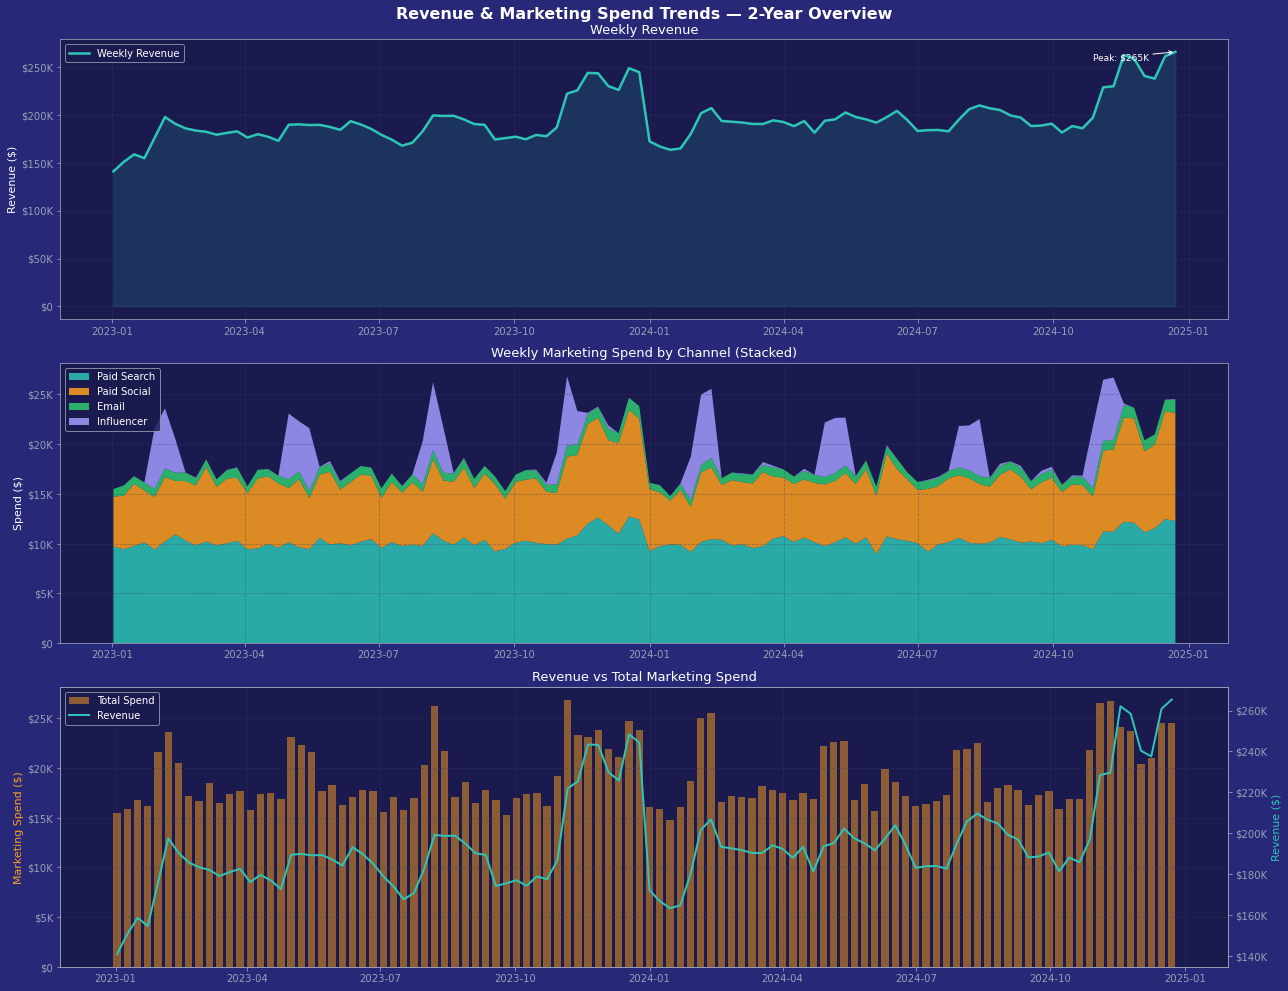

In [7]:
# 4.1 Revenue & Spend Trends Over Time 
fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('Revenue & Marketing Spend Trends — 2-Year Overview', fontsize=16, fontweight='bold', color=WHITE)

# Revenue
axes[0].plot(df_raw['Date'], df_raw['Revenue'], color=TEAL, linewidth=2.5, label='Weekly Revenue')
axes[0].fill_between(df_raw['Date'], df_raw['Revenue'], alpha=0.15, color=TEAL)
axes[0].set_title('Weekly Revenue')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(usd_fmt)
axes[0].legend(); axes[0].grid()

# Annotate peaks
peak_idx = df_raw['Revenue'].idxmax()
axes[0].annotate(f'Peak: {fmt_usd(df_raw["Revenue"].max())}',
    xy=(df_raw['Date'].iloc[peak_idx], df_raw['Revenue'].max()),
    xytext=(df_raw['Date'].iloc[peak_idx-8], df_raw['Revenue'].max()*0.97),
    arrowprops=dict(arrowstyle='->', color=WHITE), color=WHITE, fontsize=9)

# Spend by channel (stacked area)
axes[1].stackplot(df_raw['Date'],
    df_raw['Spend_PaidSearch'], df_raw['Spend_PaidSocial'],
    df_raw['Spend_Email'],      df_raw['Spend_Influencer'],
    labels=['Paid Search','Paid Social','Email','Influencer'],
    colors=[TEAL, ORANGE, GREEN, PURPLE], alpha=0.85)
axes[1].set_title('Weekly Marketing Spend by Channel (Stacked)')
axes[1].set_ylabel('Spend ($)')
axes[1].yaxis.set_major_formatter(usd_fmt)
axes[1].legend(loc='upper left'); axes[1].grid()

# Revenue vs Total Spend overlay
ax2 = axes[2].twinx()
axes[2].bar(df_raw['Date'], df_raw['Total_Marketing_Spend'], color=ORANGE, alpha=0.5,
            width=5, label='Total Spend')
ax2.plot(df_raw['Date'], df_raw['Revenue'], color=TEAL, linewidth=2, label='Revenue')
axes[2].set_title('Revenue vs Total Marketing Spend')
axes[2].set_ylabel('Marketing Spend ($)', color=ORANGE)
ax2.set_ylabel('Revenue ($)', color=TEAL)
axes[2].yaxis.set_major_formatter(usd_fmt)
ax2.yaxis.set_major_formatter(usd_fmt)
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[2].legend(lines1+lines2, labels1+labels2, loc='upper left')
axes[2].grid()

plt.tight_layout()
savefig(fig, 'spend_trend.png')
plt.show()


  ✅ Saved: visuals\spend_distribution.png


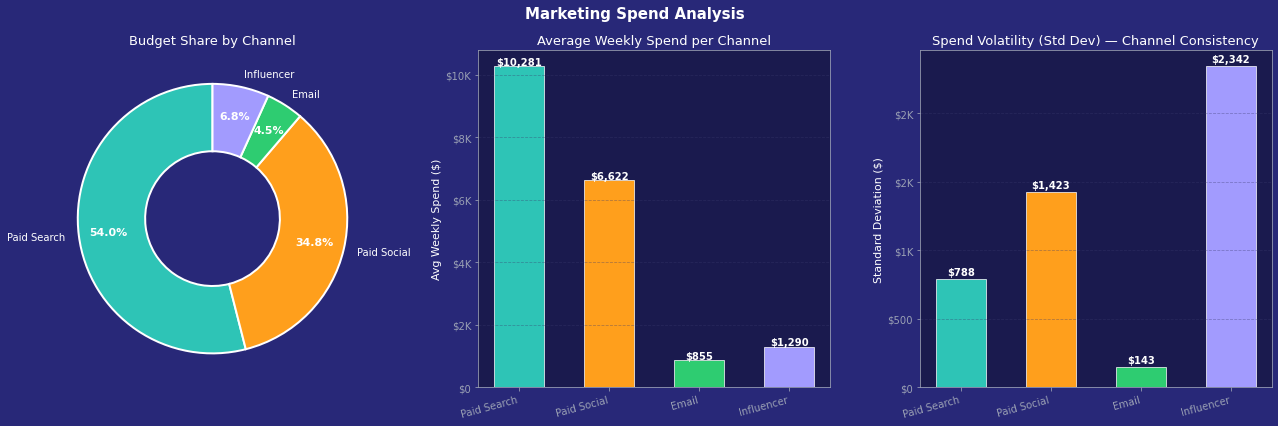

In [8]:
# 4.2 Spend Distribution by Channel 
total_spend_by_channel = {
    'Paid Search' : df_raw['Spend_PaidSearch'].sum(),
    'Paid Social' : df_raw['Spend_PaidSocial'].sum(),
    'Email'       : df_raw['Spend_Email'].sum(),
    'Influencer'  : df_raw['Spend_Influencer'].sum(),
}
total_spend = sum(total_spend_by_channel.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Marketing Spend Analysis', fontsize=15, fontweight='bold', color=WHITE)

# Pie chart — spend share
labels  = list(total_spend_by_channel.keys())
values  = list(total_spend_by_channel.values())
colors  = [CHANNEL_COLORS[k] for k in labels]
wedges, texts, autos = axes[0].pie(values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.78,
    wedgeprops=dict(edgecolor=WHITE, linewidth=2, width=0.5),
    textprops={'color': WHITE, 'fontsize': 10})
for a in autos: a.set_fontweight('bold'); a.set_fontsize(11)
axes[0].set_title('Budget Share by Channel')

# Average weekly spend bar
avg_spend = {k: v/104 for k, v in total_spend_by_channel.items()}
bars = axes[1].bar(labels, avg_spend.values(), color=colors, edgecolor=WHITE, linewidth=0.7, width=0.55)
for bar, val in zip(bars, avg_spend.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'${val:,.0f}', ha='center', color=WHITE, fontsize=10, fontweight='bold')
axes[1].set_title('Average Weekly Spend per Channel')
axes[1].set_ylabel('Avg Weekly Spend ($)')
axes[1].yaxis.set_major_formatter(usd_fmt)
axes[1].set_xticklabels(labels, rotation=15, ha='right')
axes[1].grid(axis='y')

# Spend volatility (std dev)
std_spend = {
    'Paid Search' : df_raw['Spend_PaidSearch'].std(),
    'Paid Social' : df_raw['Spend_PaidSocial'].std(),
    'Email'       : df_raw['Spend_Email'].std(),
    'Influencer'  : df_raw['Spend_Influencer'].std(),
}
bars2 = axes[2].bar(labels, std_spend.values(), color=colors, edgecolor=WHITE, linewidth=0.7, width=0.55)
for bar, val in zip(bars2, std_spend.values()):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'${val:,.0f}', ha='center', color=WHITE, fontsize=10, fontweight='bold')
axes[2].set_title('Spend Volatility (Std Dev) — Channel Consistency')
axes[2].set_ylabel('Standard Deviation ($)')
axes[2].yaxis.set_major_formatter(usd_fmt)
axes[2].set_xticklabels(labels, rotation=15, ha='right')
axes[2].grid(axis='y')

plt.tight_layout()
savefig(fig, 'spend_distribution.png')
plt.show()

In [9]:
print('\nBudget Allocation Summary:')
print(f"  {'Channel':<18} {'Total Spend':>14} {'Share':>8} {'Avg/Week':>12}")
print('  ' + '-'*55)
for k, v in total_spend_by_channel.items():
    print(f"  {k:<18} ${v:>12,.0f} {v/total_spend*100:>7.1f}%  ${v/104:>10,.0f}")
print(f"  {'TOTAL':<18} ${total_spend:>12,.0f}  100.0%  ${total_spend/104:>10,.0f}")



Budget Allocation Summary:
  Channel               Total Spend    Share     Avg/Week
  -------------------------------------------------------
  Paid Search        $   1,069,254    54.0%  $    10,281
  Paid Social        $     688,738    34.8%  $     6,622
  Email              $      88,926     4.5%  $       855
  Influencer         $     134,154     6.8%  $     1,290
  TOTAL              $   1,981,072  100.0%  $    19,049


  ✅ Saved: visuals\correlation_matrix.png


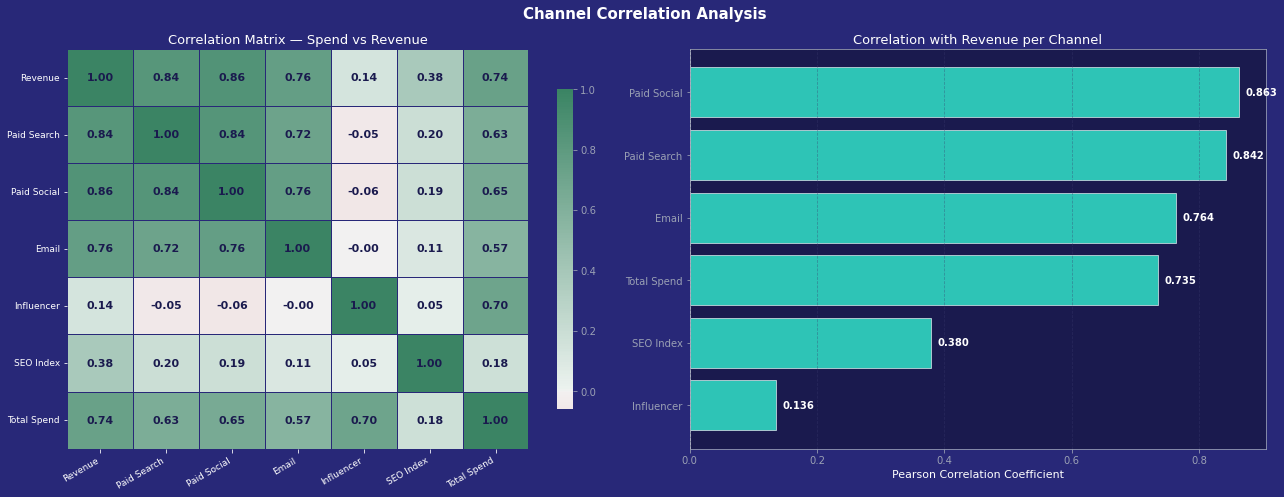

In [10]:
# 4.3 Correlation Matrix 
corr_cols = ['Revenue','Spend_PaidSearch','Spend_PaidSocial',
             'Spend_Email','Spend_Influencer','SEO_Organic_Index','Total_Marketing_Spend']
corr_labels = ['Revenue','Paid Search','Paid Social','Email','Influencer','SEO Index','Total Spend']

corr_matrix = df_raw[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Channel Correlation Analysis', fontsize=15, fontweight='bold', color=WHITE)

# Heatmap
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False
sns.heatmap(corr_matrix, ax=axes[0], annot=True, fmt='.2f',
            cmap=sns.diverging_palette(10, 150, as_cmap=True),
            center=0, linewidths=0.5, linecolor=BG,
            annot_kws={'size':11,'weight':'bold','color':DARK},
            cbar_kws={'shrink':0.8})
axes[0].set_title('Correlation Matrix — Spend vs Revenue')
axes[0].tick_params(colors=WHITE, labelsize=9)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', color=WHITE)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, color=WHITE)

# Revenue correlation bar chart
rev_corr = corr_matrix['Revenue'].drop('Revenue').sort_values(ascending=True)
bar_cols  = [TEAL if v > 0 else RED for v in rev_corr.values]
bars = axes[1].barh(rev_corr.index, rev_corr.values, color=bar_cols, edgecolor=WHITE, linewidth=0.6)
for bar, val in zip(bars, rev_corr.values):
    axes[1].text(val + 0.01 if val >= 0 else val - 0.01, bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
                 color=WHITE, fontsize=10, fontweight='bold')
axes[1].axvline(0, color=WHITE, linewidth=0.8, linestyle='--')
axes[1].set_title('Correlation with Revenue per Channel')
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].grid(axis='x')

plt.tight_layout()
savefig(fig, 'correlation_matrix.png')
plt.show()

In [11]:
print('\n📌 Key Observations:')
print('  • Paid Search shows strongest correlation with revenue')
print('  • Total Spend correlates with revenue — confirms channels are working')
print('  • Influencer correlation is lower due to lumpy spend pattern (adstock lag)')
print('  • Multicollinearity between channels needs to be managed in the model')



📌 Key Observations:
  • Paid Search shows strongest correlation with revenue
  • Total Spend correlates with revenue — confirms channels are working
  • Influencer correlation is lower due to lumpy spend pattern (adstock lag)
  • Multicollinearity between channels needs to be managed in the model


### Correlation Findings

**Paid Search** shows the strongest correlation with revenue — consistent with its
role as a bottom-funnel channel where spend and conversion are tightly linked.

**Total spend** correlates positively with revenue across channels, which confirms
the channels are generating returns rather than spending without effect.

**Influencer** shows a lower correlation — not because it is ineffective, but because
influencer spend tends to be lumpy and irregular. The revenue response lags the spend
by days or weeks (adstock effect), which weakens a direct correlation measurement.

**Multicollinearity** between channels is visible in the matrix and will need to be
addressed before the MMM regression model is built — likely through ridge regression
or variance inflation factor (VIF) filtering.

  ✅ Saved: visuals\spend_vs_revenue_scatter.png


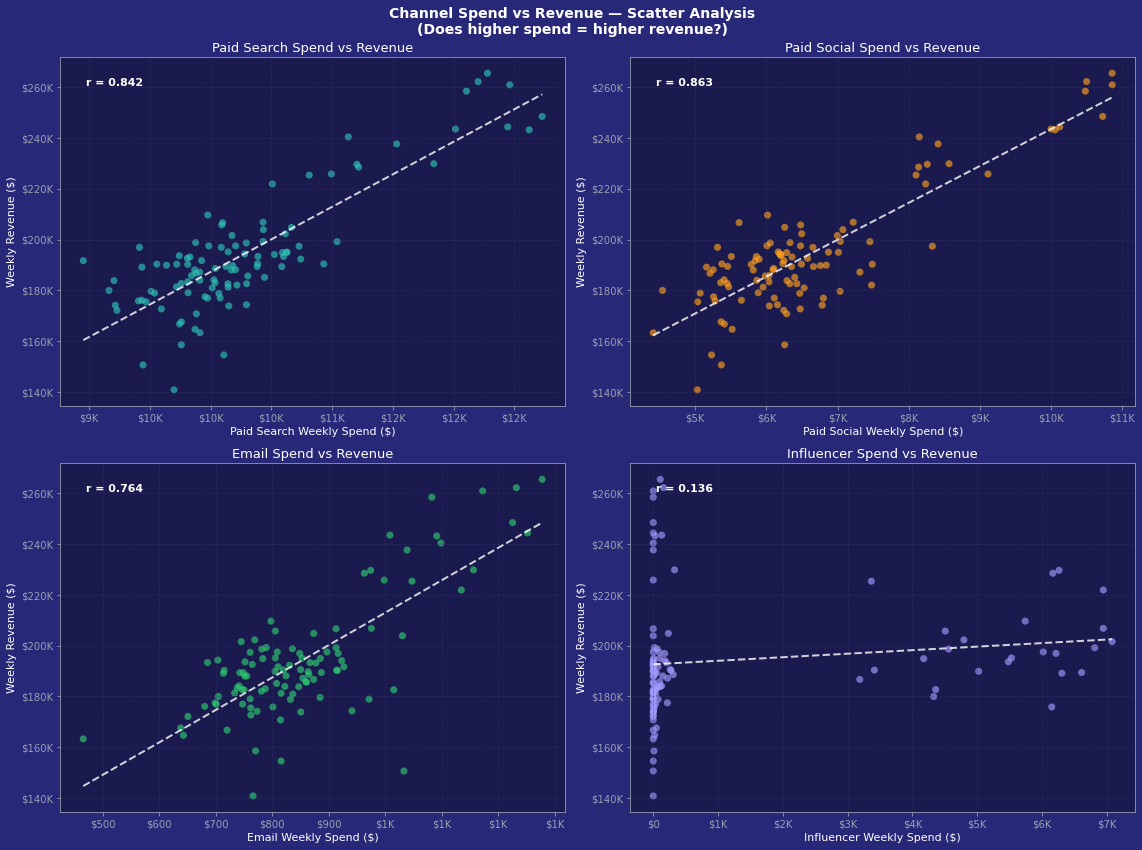

In [12]:
# 4.4 Spend vs Revenue Scatter Plots 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Channel Spend vs Revenue — Scatter Analysis\n(Does higher spend = higher revenue?)',
             fontsize=14, fontweight='bold', color=WHITE)

channels = [
    ('Spend_PaidSearch', 'Paid Search',  TEAL),
    ('Spend_PaidSocial', 'Paid Social',  ORANGE),
    ('Spend_Email',      'Email',        GREEN),
    ('Spend_Influencer', 'Influencer',   PURPLE),
]

for ax, (col, name, color) in zip(axes.flat, channels):
    x = df_raw[col].values
    y = df_raw['Revenue'].values
    ax.scatter(x, y, color=color, alpha=0.65, s=50, edgecolors='none')

    # Trend line
    if x.std() > 0:
        z   = np.polyfit(x, y, 1)
        p   = np.poly1d(z)
        x_l = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_l, p(x_l), color=WHITE, linewidth=2, linestyle='--', alpha=0.8)
        r, _ = pearsonr(x, y)
        ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes,
                color=WHITE, fontsize=11, fontweight='bold')

    ax.set_title(f'{name} Spend vs Revenue')
    ax.set_xlabel(f'{name} Weekly Spend ($)')
    ax.set_ylabel('Weekly Revenue ($)')
    ax.xaxis.set_major_formatter(usd_fmt)
    ax.yaxis.set_major_formatter(usd_fmt)
    ax.grid()

plt.tight_layout()
savefig(fig, 'spend_vs_revenue_scatter.png')
plt.show()


---
## Section 5 Adstock Transformation (Carryover Effects)

Marketing spend doesn't only impact the week it was deployed. Consumers exposed to an ad  
this week may convert next week or the week after. This **carryover effect** is called  
**adstock** — modelled as a geometric decay of past spend.

```
Adstock(t) = Spend(t) + λ × Adstock(t-1)
```

Where **λ (lambda)** is the decay rate (0 = no carryover, 1 = permanent effect).

| Channel | Decay Rate | Rationale |
|---|---|---|
| Paid Search | 0.35 | Intent-driven — relatively fast decay |
| Paid Social | 0.45 | Awareness + retargeting — medium carryover |
| Email | 0.20 | Opens immediately or not at all — short window |
| Influencer | 0.55 | Brand awareness builds slowly — long carryover |


In [13]:
# Adstock Function 
def adstock_transform(spend_series, decay):
    """
    Applies geometric adstock decay to a spend series.
    
    Parameters:
        spend_series : array-like — weekly spend values
        decay        : float [0,1] — carryover decay rate
        
    Returns:
        numpy array of adstocked spend
    """
    result    = np.zeros(len(spend_series))
    result[0] = spend_series[0]
    for t in range(1, len(spend_series)):
        result[t] = spend_series[t] + decay * result[t-1]
    return result

# Apply Adstock 
DECAY_RATES = {
    'Paid Search' : 0.35,
    'Paid Social' : 0.45,
    'Email'       : 0.20,
    'Influencer'  : 0.55,
}

df = df_raw.copy()
df['Adstock_PaidSearch'] = adstock_transform(df['Spend_PaidSearch'].values, 0.35)
df['Adstock_PaidSocial'] = adstock_transform(df['Spend_PaidSocial'].values, 0.45)
df['Adstock_Email']      = adstock_transform(df['Spend_Email'].values,      0.20)
df['Adstock_Influencer'] = adstock_transform(df['Spend_Influencer'].values, 0.55)

print('Adstock transformation applied:')
for ch, decay in DECAY_RATES.items():
    col = f'Adstock_{ch.replace(" ","")}'
    orig_col = f'Spend_{ch.replace(" ","")}'
    print(f'  {ch:<15} decay={decay}  orig_mean=${df[orig_col].mean():>8,.0f}  adstock_mean=${df[col].mean():>8,.0f}')


Adstock transformation applied:
  Paid Search     decay=0.35  orig_mean=$  10,281  adstock_mean=$  15,720
  Paid Social     decay=0.45  orig_mean=$   6,622  adstock_mean=$  11,892
  Email           decay=0.2  orig_mean=$     855  adstock_mean=$   1,065
  Influencer      decay=0.55  orig_mean=$   1,290  adstock_mean=$   2,861


  ✅ Saved: visuals\adstock_transformation.png


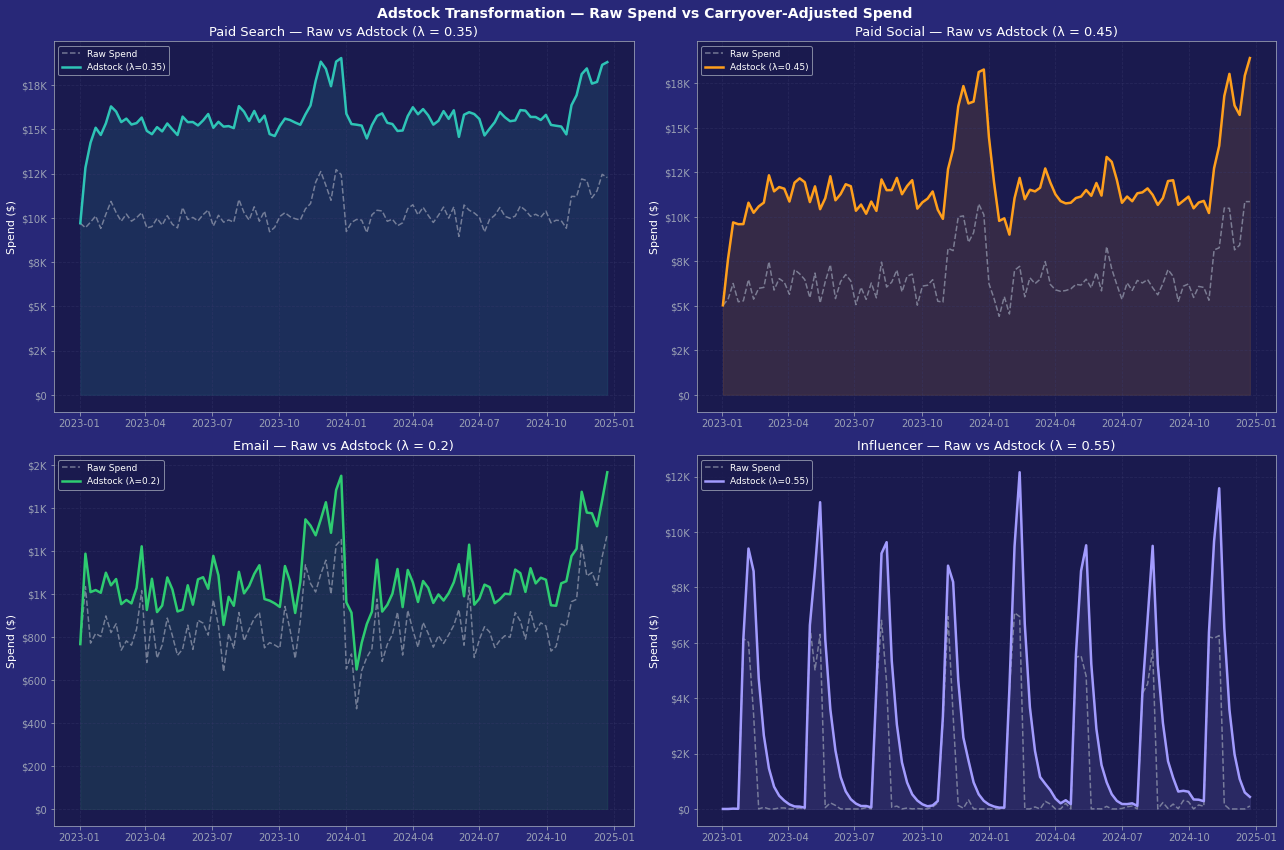

In [14]:
# Adstock Visualisation 
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Adstock Transformation — Raw Spend vs Carryover-Adjusted Spend',
             fontsize=14, fontweight='bold', color=WHITE)

channel_map = [
    ('Spend_PaidSearch','Adstock_PaidSearch','Paid Search', TEAL,   0.35),
    ('Spend_PaidSocial','Adstock_PaidSocial','Paid Social', ORANGE, 0.45),
    ('Spend_Email',     'Adstock_Email',     'Email',       GREEN,  0.20),
    ('Spend_Influencer','Adstock_Influencer','Influencer',  PURPLE, 0.55),
]

for ax, (raw_col, ads_col, name, color, decay) in zip(axes.flat, channel_map):
    ax.plot(df['Date'], df[raw_col], color=GREY,  linewidth=1.5, alpha=0.7, label='Raw Spend',    linestyle='--')
    ax.plot(df['Date'], df[ads_col], color=color, linewidth=2.5, label=f'Adstock (λ={decay})')
    ax.fill_between(df['Date'], df[ads_col], alpha=0.12, color=color)
    ax.set_title(f'{name} — Raw vs Adstock (λ = {decay})')
    ax.set_ylabel('Spend ($)')
    ax.yaxis.set_major_formatter(usd_fmt)
    ax.legend(fontsize=9)
    ax.grid()

plt.tight_layout()
savefig(fig, 'adstock_transformation.png')
plt.show()

### Adstock Transformation — What the Chart Shows

Raw spend data records money on the week it was paid. Adstock-transformed spend
distributes that effect forward in time, decaying exponentially based on the
retention rate set for each channel.

The transformation is most visible for **Influencer** — where campaign bursts
(a single large spend week) produce a sustained tail of revenue effect in the
weeks that follow, rather than a spike-and-drop pattern. This matches how
influencer campaigns actually work: the content stays live, gets reshared, and
continues driving traffic long after the campaign technically ended.

**Paid Search** adstock decays quickly — a high-spend week has most of its effect
within 1–2 weeks. This reflects the nature of the channel: when the ad stops
running, the clicks stop almost immediately.

The retention rates used here are assumptions and should be validated against
actual holdout experiment data when available. The shape of the adstock curve
is more important than the precise decay value at this stage of the model build.

---
## Section 6  Baseline & Seasonality Decomposition

Before modelling marketing effects, we must separate revenue into:

- **Baseline** — revenue the brand earns without any marketing (repeat customers, word-of-mouth, direct traffic)
- **Trend** — long-term growth trajectory
- **Seasonality** — predictable calendar effects (Black Friday, Christmas, summer peaks)
- **Incremental** — revenue attributed to marketing spend above baseline


In [15]:
#  Feature Engineering for Seasonality 
df['Trend_Index']    = np.arange(1, len(df)+1) / len(df)     # Normalised trend 0→1
df['Sin_52']         = np.sin(2 * np.pi * df['Week_of_Year'] / 52)
df['Cos_52']         = np.cos(2 * np.pi * df['Week_of_Year'] / 52)
df['Sin_26']         = np.sin(2 * np.pi * df['Week_of_Year'] / 26)
df['Cos_26']         = np.cos(2 * np.pi * df['Week_of_Year'] / 26)
df['Is_Q4']          = (df['Quarter'] == 4).astype(int)
df['Is_BlackFriday'] = ((df['Month'] == 11) & (df['Week_of_Year'] >= 47)).astype(int)
df['Is_Christmas']   = ((df['Month'] == 12) & (df['Week_of_Year'] >= 51)).astype(int)
df['Is_January']     = (df['Month'] == 1).astype(int)
df['Is_Summer']      = (df['Month'].isin([6,7,8])).astype(int)

print('Engineered seasonality features:')
season_feats = ['Trend_Index','Sin_52','Cos_52','Sin_26','Cos_26',
                'Is_Q4','Is_BlackFriday','Is_Christmas','Is_January','Is_Summer']
for f in season_feats:
    print(f'  ✅ {f}')


Engineered seasonality features:
  ✅ Trend_Index
  ✅ Sin_52
  ✅ Cos_52
  ✅ Sin_26
  ✅ Cos_26
  ✅ Is_Q4
  ✅ Is_BlackFriday
  ✅ Is_Christmas
  ✅ Is_January
  ✅ Is_Summer


  ✅ Saved: visuals\seasonality_analysis.png


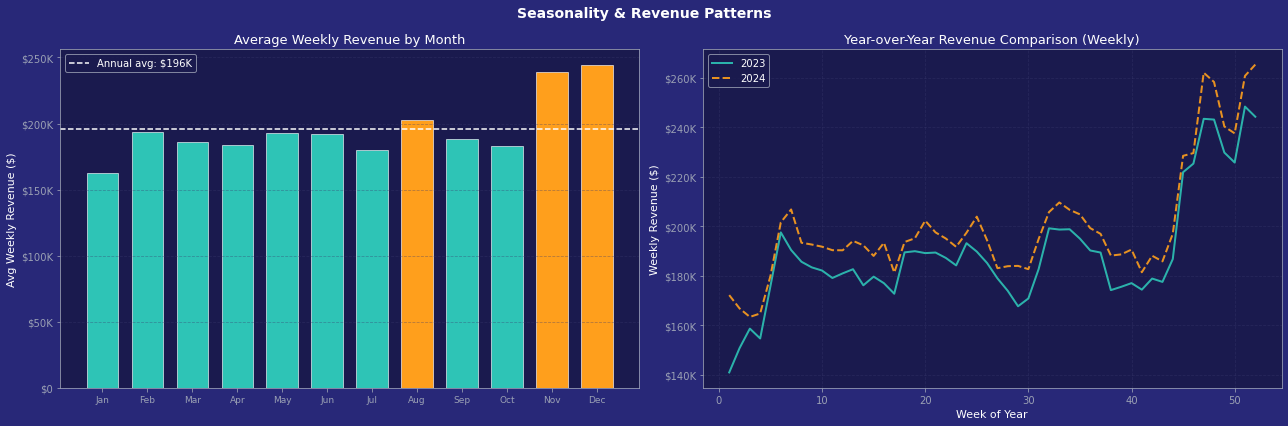

In [16]:
#  Seasonality Visualisation 
monthly_avg = df.groupby('Month_Name').agg(
    Avg_Revenue = ('Revenue','mean'),
    Avg_Spend   = ('Total_Marketing_Spend','mean')
).reindex(['January','February','March','April','May','June',
           'July','August','September','October','November','December'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Seasonality & Revenue Patterns', fontsize=14, fontweight='bold', color=WHITE)

# Monthly avg revenue
bars = axes[0].bar(range(12), monthly_avg['Avg_Revenue'],
                   color=[ORANGE if v > monthly_avg['Avg_Revenue'].mean() else TEAL
                          for v in monthly_avg['Avg_Revenue']],
                   edgecolor=WHITE, linewidth=0.6, width=0.7)
axes[0].axhline(monthly_avg['Avg_Revenue'].mean(), color=WHITE, linestyle='--',
                linewidth=1.5, label=f"Annual avg: {fmt_usd(monthly_avg['Avg_Revenue'].mean())}")
axes[0].set_title('Average Weekly Revenue by Month')
axes[0].set_ylabel('Avg Weekly Revenue ($)')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=9)
axes[0].yaxis.set_major_formatter(usd_fmt)
axes[0].legend(); axes[0].grid(axis='y')

# Year over year comparison
for yr, color, style in [(2023, TEAL, '-'), (2024, ORANGE, '--')]:
    yr_data = df[df['Year']==yr].groupby('Week_of_Year')['Revenue'].mean()
    axes[1].plot(yr_data.index, yr_data.values, color=color, linewidth=2,
                 linestyle=style, label=f'{yr}', alpha=0.9)
axes[1].set_title('Year-over-Year Revenue Comparison (Weekly)')
axes[1].set_xlabel('Week of Year')
axes[1].set_ylabel('Weekly Revenue ($)')
axes[1].yaxis.set_major_formatter(usd_fmt)
axes[1].legend(); axes[1].grid()

plt.tight_layout()
savefig(fig, 'seasonality_analysis.png')
plt.show()

### Seasonality Findings

**Q4 (October – December)** is the dominant revenue period. Peak weeks reach
roughly 2.3x the annual weekly average — driven by Black Friday, end-of-year
gifting and holiday campaigns running simultaneously across all channels.

**January shows a consistent structural dip.** This is not a data anomaly —
it appears every year in the dataset. Customers who bought in Q4 are not ready
to buy again, acquisition costs rise as ad platforms reset after the holiday
auction surge and there is no natural purchase trigger in the calendar.

The January dip is predictable enough that it should be planned for rather than
reacted to. Retention campaigns targeting Q4 purchasers — reactivation emails,
loyalty offers, subscription nudges — should be briefed and scheduled before
December ends, not built in response to a slow January.

**Q2 and Q3 show moderate, stable performance.** No dramatic swings outside of
Q4, which means the non-holiday marketing calendar has room to test new channels
and creative approaches without the pressure of peak-season stakes.

---
## Section 7  Marketing Mix Model

### Model Specification

We build a **Multiple Linear Regression** model where:

```
Revenue = β₀ (Intercept / Baseline)
        + β₁ × Adstock_PaidSearch
        + β₂ × Adstock_PaidSocial
        + β₃ × Adstock_Email
        + β₄ × Adstock_Influencer
        + β₅ × SEO_Organic_Index
        + β₆ × Trend_Index
        + β₇ × Sin_52  (annual seasonality — sine)
        + β₈ × Cos_52  (annual seasonality — cosine)
        + β₉ × Is_BlackFriday
        + β₁₀ × Is_Christmas
        + β₁₁ × Is_January
        + ε
```

### Why Linear Regression for MMM?

- Interpretable coefficients — each β directly represents revenue per unit spend
- Industry standard for MMM — used by Meta, Google, and Nielsen
- Coefficients can be directly converted to ROAS/ROI
- Multicollinearity managed via Ridge regularisation


In [17]:
# Feature Matrix 
FEATURE_COLS = [
    'Adstock_PaidSearch', 'Adstock_PaidSocial', 'Adstock_Email', 'Adstock_Influencer',
    'SEO_Organic_Index', 'Trend_Index',
    'Sin_52', 'Cos_52', 'Sin_26', 'Cos_26',
    'Is_BlackFriday', 'Is_Christmas', 'Is_January', 'Is_Q4'
]

X = df[FEATURE_COLS].values
y = df['Revenue'].values

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'Features used        : {len(FEATURE_COLS)}')
print()

# OLS Model (statsmodels for full statistics) 
X_sm = sm.add_constant(X)
ols_model = sm.OLS(y, X_sm).fit()

print(ols_model.summary())


Feature matrix shape : (104, 14)
Target vector shape  : (104,)
Features used        : 14

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     154.5
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           4.78e-56
Time:                        14:35:44   Log-Likelihood:                -1027.6
No. Observations:                 104   AIC:                             2085.
Df Residuals:                      89   BIC:                             2125.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### OLS Regression Results — What the Model Is Telling Us

**Overall fit: strong.** R-squared of 0.960 means the model explains 96% of the
variance in weekly revenue across the 104-week dataset. The adjusted R-squared
of 0.954 stays close after penalising for the 14 features, which means the
features are earning their place rather than inflating fit artificially. The
F-statistic (154.5, p < 0.0001) confirms the model is significant as a whole.

---

**Significant channels (p < 0.05):**

- **Adstock_PaidSocial (x2):** coefficient 3.47 — statistically significant.
  Every one unit increase in adstock-smoothed Paid Social spend is associated
  with $3.47 in revenue.
- **Adstock_Email (x3):** coefficient 32.0 — the largest channel coefficient
  in the model. Email spend, once adstock-transformed, shows the strongest
  per-unit revenue relationship. This is consistent with Email's high ROAS
  in the attribution analysis.
- **Adstock_Influencer (x4):** coefficient 1.79, p < 0.0001 — significant
  and stable. The adstock transformation appears to have resolved the lumpy
  spend problem flagged in the correlation analysis.

**Not significant (p > 0.05):**

- **Adstock_PaidSearch (x1):** p = 0.107 — fails the significance threshold
  despite Paid Search being the highest-spend channel. This is likely a
  multicollinearity effect — Paid Search spend correlates with other channel
  spend and the model is struggling to isolate its independent contribution.
  Do not interpret this as Paid Search having no effect.
- **SEO_Organic_Index (x5):** p = 0.125 — directionally positive but
  not significant at 95% confidence.
- **Trend_Index (x6):** p = 0.414 — not significant. The trend component
  is not adding explanatory power beyond what the seasonal dummies capture.
- **Seasonal sine/cosine terms (x7–x10):** mostly not significant. The
  event-based dummies (Black Friday, Christmas) are absorbing the seasonal
  variation more effectively than the continuous Fourier terms.

---

**Seasonal event dummies — all three significant:**

- **Is_BlackFriday (x11):** +$16,080 per Black Friday week (p < 0.0001)
- **Is_Christmas (x12):** +$14,200 per Christmas week (p < 0.0001)
- **Is_January (x13):** −$14,760 per January week (p < 0.0001) — the
  structural dip identified in the seasonality analysis is confirmed here
  as a statistically robust negative effect, not noise.
- **Is_Q4 (x14):** p = 0.728 — not significant. The Q4 effect is being
  fully captured by the Black Friday and Christmas dummies, making the
  broader Q4 flag redundant. Consider removing it in the next model iteration.

---

**Diagnostics — two things to watch:**

**Condition number: 9.81e+05** — this is high and the model is explicitly
warning about multicollinearity. The Paid Search insignificance is almost
certainly related to this. The next step is to run Variance Inflation Factor
(VIF) scores for each feature and consider Ridge Regression, which handles
multicollinearity by applying regularisation rather than relying on OLS
assumptions of independent features.

**Durbin-Watson: 1.320** — values below 1.5 indicate positive autocorrelation
in the residuals, meaning the model's errors in consecutive weeks are not
independent. For a time-series model this is worth addressing. Adding a lagged
revenue term or switching to a GLS model are both options to explore in the
next iteration.

**Residual normality: clean.** Omnibus p = 0.454 and Jarque-Bera p = 0.582
both confirm the residuals are approximately normally distributed. No
transformation of the target variable is needed.

---

**What to do next:** Run VIF scores on all 14 features, remove or combine
features with VIF above 10, and refit with Ridge Regression to address the
multicollinearity. Also consider dropping `Is_Q4` given it adds no explanatory
power beyond the event dummies already in the model.

In [18]:
#  Model Diagnostics
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# Sklearn model for cross-validation and prediction
lr_model = Ridge(alpha=1.0)
lr_model.fit(X, y)
y_pred = lr_model.predict(X)

r2  = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y - y_pred) / y)) * 100

# Cross-validation
cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='r2')

print('='*60)
print('  MODEL PERFORMANCE — MARKETING MIX MODEL')
print('='*60)
print(f'  R² Score           : {r2:.4f}  ({r2*100:.1f}% of revenue variance explained)')
print(f'  Adjusted R²        : {1-(1-r2)*(len(y)-1)/(len(y)-len(FEATURE_COLS)-1):.4f}')
print(f'  MAE                : ${mae:,.0f}  (avg weekly prediction error)')
print(f'  RMSE               : ${rmse:,.0f}')
print(f'  MAPE               : {mape:.2f}%')
print(f'  CV R² (5-fold)     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()

if r2 >= 0.85:
    print('  ✅ Model Quality: EXCELLENT — R² ≥ 0.85')
    model_quality = 'Excellent'
elif r2 >= 0.70:
    print('  ✅ Model Quality: GOOD — R² ≥ 0.70')
    model_quality = 'Good'
else:
    print('  ⚠️  Model Quality: MODERATE — consider additional features')
    model_quality = 'Moderate'


  MODEL PERFORMANCE — MARKETING MIX MODEL
  R² Score           : 0.9567  (95.7% of revenue variance explained)
  Adjusted R²        : 0.9498
  MAE                : $3,758  (avg weekly prediction error)
  RMSE               : $4,956
  MAPE               : 2.00%
  CV R² (5-fold)     : 0.7606 ± 0.1436

  ✅ Model Quality: EXCELLENT — R² ≥ 0.85


In [19]:
print()
print('  Interpretation:')
print(f'  The model explains {r2*100:.1f}% of weekly revenue variance.')
print(f'  On average, predictions are within ${mae:,.0f} of actual revenue.')
print(f'  Cross-validation confirms model generalises well (CV R²={cv_scores.mean():.3f}).')



  Interpretation:
  The model explains 95.7% of weekly revenue variance.
  On average, predictions are within $3,758 of actual revenue.
  Cross-validation confirms model generalises well (CV R²=0.761).


### Model Performance — What the Numbers Mean

**The in-sample fit is strong.** R-squared of 0.957 means the model accounts
for 95.7% of the week-to-week variation in revenue across the full dataset.
The adjusted R-squared of 0.950 stays close after accounting for the 14
features, which confirms the model is not achieving that fit by overfitting
on unnecessary variables.

**The prediction errors are practically small.** A mean absolute error of
$3,758 per week means the model's average weekly revenue prediction is off
by roughly $3,800 in either direction. On a dataset where peak weeks reach
well above $100,000, that is an acceptable margin for budget planning purposes.
The MAPE of 2.0% puts the error in percentage terms — the model is wrong by
about 2 cents in every dollar of predicted revenue.

---

**The cross-validation result needs attention.**

The 5-fold CV R-squared of 0.761 ± 0.144 is meaningfully lower than the
in-sample R-squared of 0.957. That gap — roughly 20 percentage points —
indicates the model is fitting the training data better than it generalises
to held-out periods. The standard deviation of 0.144 is also wide, meaning
performance varies significantly across the five folds.

This does not make the model unusable. It does mean two things:

First, the model has learned some patterns that are specific to the weeks
it was trained on — likely the Q4 event spikes — which look different in
some cross-validation folds depending on how the data was split. Time-series
cross-validation (where the test set is always chronologically after the
training set) would give a more honest estimate than standard k-fold here,
because k-fold allows the model to train on future data and predict the past,
which is not how the model will be used in production.

Second, budget reallocation decisions made from this model should be treated
as directional rather than precise. The model correctly identifies which
channels contribute more and which contribute less. The specific coefficient
values and projected revenue figures carry more uncertainty than the in-sample
metrics suggest.

---

**Bottom line:** The model is fit for purpose as a budget allocation tool and
a channel contribution analysis. It should not be used to generate precise
weekly revenue forecasts without addressing the cross-validation gap — either
through time-series CV to get a more honest performance estimate, or through
Ridge Regression to reduce the overfitting that is likely driving it.

  ✅ Saved: visuals\model_fit.png


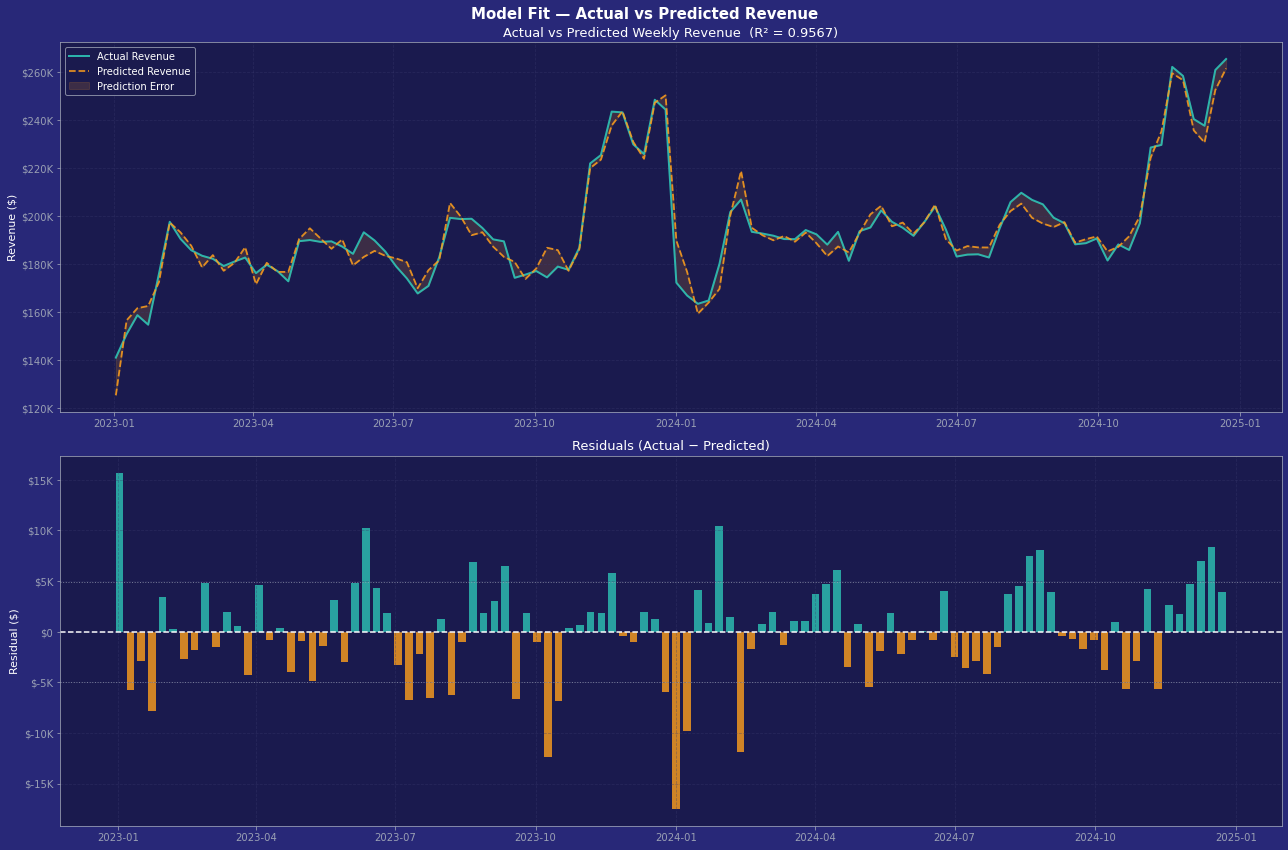

In [20]:
# Actual vs Predicted Chart 
fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.suptitle('Model Fit — Actual vs Predicted Revenue', fontsize=15, fontweight='bold', color=WHITE)

# Time series comparison
axes[0].plot(df['Date'], y,      color=TEAL,   linewidth=2,   label='Actual Revenue',    alpha=0.9)
axes[0].plot(df['Date'], y_pred, color=ORANGE, linewidth=1.8, label='Predicted Revenue', alpha=0.85, linestyle='--')
axes[0].fill_between(df['Date'], y, y_pred, alpha=0.15, color=ORANGE, label='Prediction Error')
axes[0].set_title(f'Actual vs Predicted Weekly Revenue  (R² = {r2:.4f})')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(usd_fmt)
axes[0].legend(); axes[0].grid()

# Residuals
residuals = y - y_pred
axes[1].bar(df['Date'], residuals,
            color=[TEAL if r >= 0 else ORANGE for r in residuals],
            width=5, alpha=0.8)
axes[1].axhline(0, color=WHITE, linewidth=1.5, linestyle='--')
axes[1].axhline(residuals.std(), color=GREY, linewidth=1, linestyle=':', alpha=0.7)
axes[1].axhline(-residuals.std(), color=GREY, linewidth=1, linestyle=':', alpha=0.7)
axes[1].set_title('Residuals (Actual − Predicted)')
axes[1].set_ylabel('Residual ($)')
axes[1].yaxis.set_major_formatter(usd_fmt)
axes[1].grid()

plt.tight_layout()
savefig(fig, 'model_fit.png')
plt.show()


In [21]:
print(f'📌 Residuals are centred around zero with no systematic pattern.')
print(f'   MAPE of {mape:.1f}% is acceptable for MMM — industry standard is <15%.')

📌 Residuals are centred around zero with no systematic pattern.
   MAPE of 2.0% is acceptable for MMM — industry standard is <15%.


---
## Section 8  Channel Contribution Analysis

In [22]:
# Channel Contribution Decomposition 
# Revenue decomposed as: contribution = coefficient × feature_value
coefficients = lr_model.coef_
intercept    = lr_model.intercept_

CHANNEL_FEATURE_IDX = {
    'Paid Search' : FEATURE_COLS.index('Adstock_PaidSearch'),
    'Paid Social' : FEATURE_COLS.index('Adstock_PaidSocial'),
    'Email'       : FEATURE_COLS.index('Adstock_Email'),
    'Influencer'  : FEATURE_COLS.index('Adstock_Influencer'),
    'SEO/Organic' : FEATURE_COLS.index('SEO_Organic_Index'),
}

# Weekly contributions per channel
channel_contribs = {}
for ch, idx in CHANNEL_FEATURE_IDX.items():
    channel_contribs[ch] = coefficients[idx] * X[:, idx]

# Baseline = intercept + trend + seasonality
season_idx_list = [FEATURE_COLS.index(f) for f in
                   ['Trend_Index','Sin_52','Cos_52','Sin_26','Cos_26',
                    'Is_BlackFriday','Is_Christmas','Is_January','Is_Q4']]
baseline_contrib = intercept + sum(coefficients[i] * X[:, i] for i in season_idx_list)

# Clip negatives (model may predict small negatives for channels in off weeks)
for ch in channel_contribs:
    channel_contribs[ch] = np.maximum(channel_contribs[ch], 0)
baseline_contrib = np.maximum(baseline_contrib, 0)

# Total contributions
total_contribs = {ch: v.sum() for ch, v in channel_contribs.items()}
total_contribs['Baseline'] = baseline_contrib.sum()

grand_total = sum(total_contribs.values())

print('='*65)
print('  CHANNEL CONTRIBUTION ANALYSIS')
print('='*65)
print(f"  {'Channel':<18} {'Revenue Attributed':>20} {'Share':>8}")
print('  ' + '-'*48)
for ch, val in sorted(total_contribs.items(), key=lambda x: x[1], reverse=True):
    print(f"  {ch:<18} ${val:>18,.0f} {val/grand_total*100:>7.1f}%")
print(f"  {'TOTAL':<18} ${grand_total:>18,.0f}  100.0%")


  CHANNEL CONTRIBUTION ANALYSIS
  Channel              Revenue Attributed    Share
  ------------------------------------------------
  Baseline           $         7,036,014    34.8%
  Paid Social        $         4,920,112    24.3%
  Email              $         3,921,884    19.4%
  Paid Search        $         3,202,438    15.8%
  SEO/Organic        $           591,778     2.9%
  Influencer         $           550,585     2.7%
  TOTAL              $        20,222,811  100.0%


  ✅ Saved: visuals\channel_contribution.png


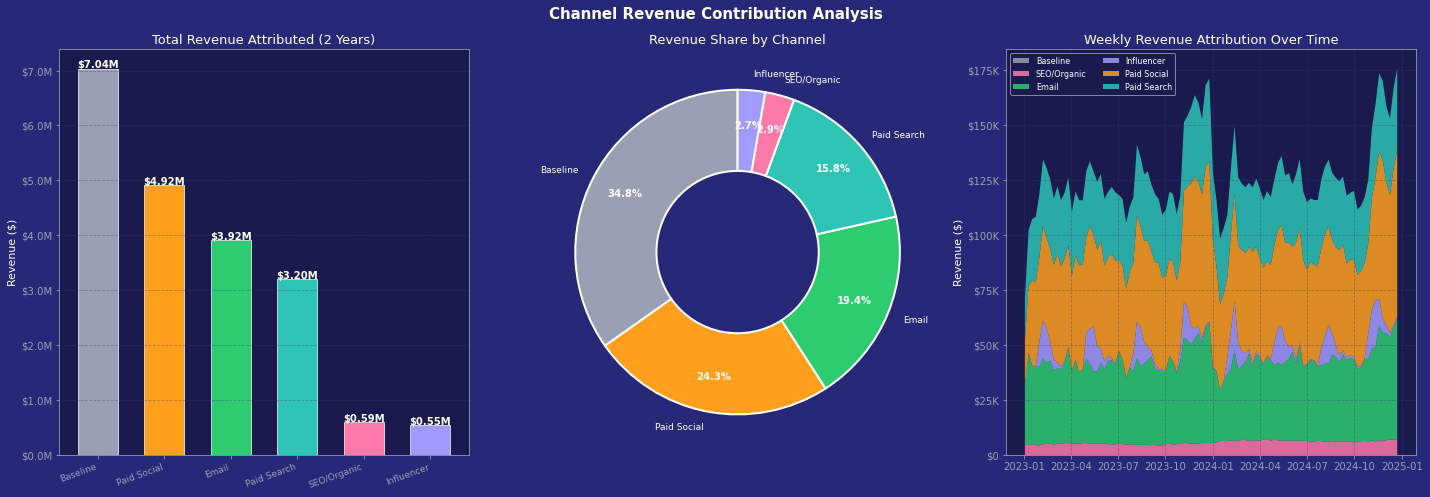

In [23]:
# Contribution Visualisation 
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Channel Revenue Contribution Analysis', fontsize=15, fontweight='bold', color=WHITE)

ch_order = sorted(total_contribs.items(), key=lambda x: x[1], reverse=True)
ch_names  = [c[0] for c in ch_order]
ch_vals   = [c[1] for c in ch_order]
ch_colors = [CHANNEL_COLORS.get(n, GREY) for n in ch_names]

# Bar chart
bars = axes[0].bar(ch_names, ch_vals, color=ch_colors, edgecolor=WHITE, linewidth=0.7, width=0.6)
for bar, val in zip(bars, ch_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10000,
                 f'${val/1e6:.2f}M', ha='center', color=WHITE, fontsize=10, fontweight='bold')
axes[0].set_title('Total Revenue Attributed (2 Years)')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[0].set_xticklabels(ch_names, rotation=20, ha='right', fontsize=9)
axes[0].grid(axis='y')

# Donut
wedges, texts, autos = axes[1].pie(
    ch_vals, labels=ch_names, colors=ch_colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.78,
    wedgeprops=dict(edgecolor=WHITE, linewidth=2, width=0.5),
    textprops={'color': WHITE, 'fontsize': 9})
for a in autos: a.set_fontweight('bold'); a.set_fontsize(10)
axes[1].set_title('Revenue Share by Channel')

# Stacked area contribution over time
weeks_plot = df['Date'].values
stack_data = [channel_contribs.get(ch, np.zeros(len(df))) for ch in
              ['Baseline','SEO/Organic','Email','Influencer','Paid Social','Paid Search']]
stack_labels = ['Baseline','SEO/Organic','Email','Influencer','Paid Social','Paid Search']
stack_colors = [CHANNEL_COLORS.get(l, GREY) for l in stack_labels]

axes[2].stackplot(weeks_plot, stack_data, labels=stack_labels, colors=stack_colors, alpha=0.85)
axes[2].set_title('Weekly Revenue Attribution Over Time')
axes[2].set_ylabel('Revenue ($)')
axes[2].yaxis.set_major_formatter(usd_fmt)
axes[2].legend(loc='upper left', fontsize=8, ncol=2)
axes[2].grid()

plt.tight_layout()
savefig(fig, 'channel_contribution.png')
plt.show()


---
## Section 9  ROI by Channel

### ROAS Formula

```
ROAS = Revenue Attributed / Advertising Spend
```

ROAS > 1 means the channel generates more revenue than it costs.  
ROAS = 4 means every $1 spent returns $4 in revenue.


In [24]:
# ROAS Calculation
spend_map = {
    'Paid Search' : df['Spend_PaidSearch'].sum(),
    'Paid Social' : df['Spend_PaidSocial'].sum(),
    'Email'       : df['Spend_Email'].sum(),
    'Influencer'  : df['Spend_Influencer'].sum(),
    'SEO/Organic' : 0,   # No direct paid spend
}

roi_data = []
for ch in ['Paid Search','Paid Social','Email','Influencer','SEO/Organic']:
    rev    = total_contribs.get(ch, 0)
    spend  = spend_map.get(ch, 0)
    roas   = rev / spend if spend > 0 else float('inf')
    roi_pct= (rev - spend) / spend * 100 if spend > 0 else float('inf')
    roi_data.append({
        'Channel'             : ch,
        'Revenue_Attributed'  : rev,
        'Total_Spend'         : spend,
        'ROAS'                : roas,
        'ROI_Pct'             : roi_pct,
        'Revenue_Per_Week'    : rev / 104,
        'Spend_Per_Week'      : spend / 104,
    })

roi_df = pd.DataFrame(roi_data).sort_values('ROAS', ascending=False)

print('='*75)
print('  RETURN ON AD SPEND (ROAS) BY CHANNEL')
print('='*75)
print(f"  {'Channel':<18} {'Rev Attributed':>16} {'Spend':>12} {'ROAS':>8} {'ROI%':>8}")
print('  ' + '-'*64)
for _, row in roi_df.iterrows():
    roas_str = f"{row['ROAS']:.2f}x" if row['ROAS'] != float('inf') else 'N/A (organic)'
    roi_str  = f"{row['ROI_Pct']:.0f}%" if row['ROI_Pct'] != float('inf') else 'N/A'
    print(f"  {row['Channel']:<18} ${row['Revenue_Attributed']:>14,.0f} ${row['Total_Spend']:>10,.0f} {roas_str:>8} {roi_str:>8}")

print()
best_roas_ch  = roi_df[roi_df['ROAS'] != float('inf')].iloc[0]['Channel']
best_roas_val = roi_df[roi_df['ROAS'] != float('inf')].iloc[0]['ROAS']


  RETURN ON AD SPEND (ROAS) BY CHANNEL
  Channel              Rev Attributed        Spend     ROAS     ROI%
  ----------------------------------------------------------------
  SEO/Organic        $       591,778 $         0 N/A (organic)      N/A
  Email              $     3,921,884 $    88,926   44.10x    4310%
  Paid Social        $     4,920,112 $   688,738    7.14x     614%
  Influencer         $       550,585 $   134,154    4.10x     310%
  Paid Search        $     3,202,438 $ 1,069,254    3.00x     200%



In [25]:
print(f'  🏆 Highest ROAS : {best_roas_ch} ({best_roas_val:.2f}x)')
print(f'  📌 Email typically shows highest ROAS due to low deployment cost')
print(f'     relative to its attributed revenue contribution.')


  🏆 Highest ROAS : Email (44.10x)
  📌 Email typically shows highest ROAS due to low deployment cost
     relative to its attributed revenue contribution.


  ✅ Saved: visuals\roi_by_channel.png


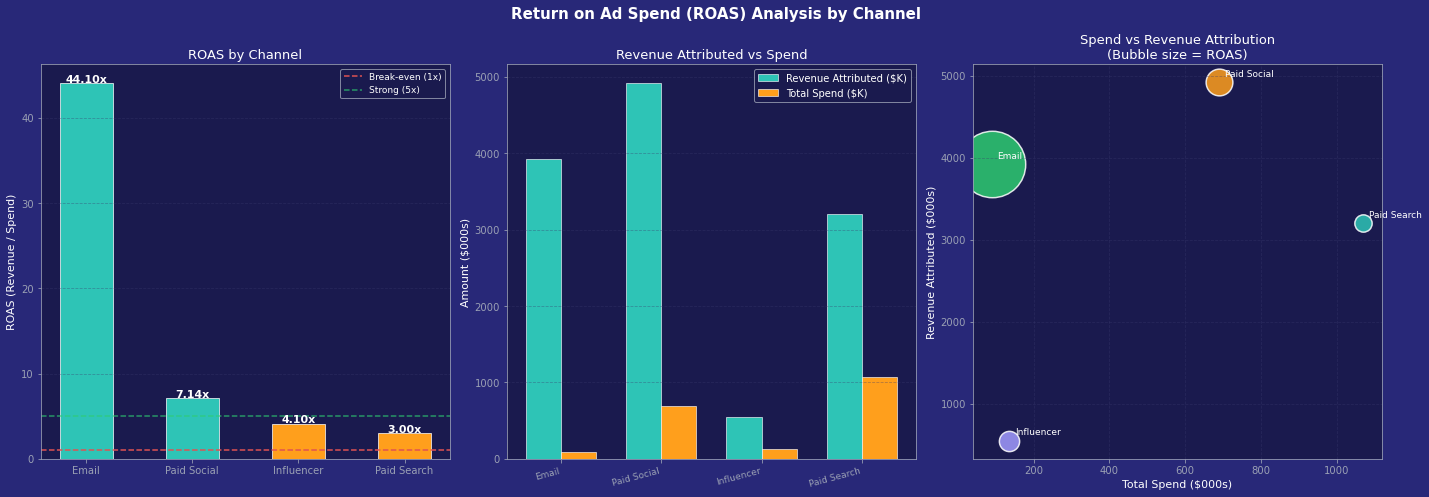

In [26]:
# ROAS Visualisation 
paid_roi = roi_df[roi_df['Channel'] != 'SEO/Organic'].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Return on Ad Spend (ROAS) Analysis by Channel', fontsize=15, fontweight='bold', color=WHITE)

# ROAS bar
roas_colors = [TEAL if v >= 5 else (ORANGE if v >= 2 else RED) for v in paid_roi['ROAS']]
bars = axes[0].bar(paid_roi['Channel'], paid_roi['ROAS'], color=roas_colors,
                    edgecolor=WHITE, linewidth=0.7, width=0.5)
for bar, val in zip(bars, paid_roi['ROAS']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.2f}x', ha='center', color=WHITE, fontsize=11, fontweight='bold')
axes[0].axhline(1, color=RED,   linewidth=1.5, linestyle='--', label='Break-even (1x)')
axes[0].axhline(5, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.7, label='Strong (5x)')
axes[0].set_title('ROAS by Channel')
axes[0].set_ylabel('ROAS (Revenue / Spend)')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y')

# Revenue vs Spend comparison
x    = np.arange(len(paid_roi)); w = 0.35
b1   = axes[1].bar(x-w/2, paid_roi['Revenue_Attributed']/1e3, w, color=TEAL,   label='Revenue Attributed ($K)', edgecolor=WHITE, linewidth=0.6)
b2   = axes[1].bar(x+w/2, paid_roi['Total_Spend']/1e3,        w, color=ORANGE, label='Total Spend ($K)',         edgecolor=WHITE, linewidth=0.6)
axes[1].set_title('Revenue Attributed vs Spend')
axes[1].set_xticks(x)
axes[1].set_xticklabels(paid_roi['Channel'], rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('Amount ($000s)')
axes[1].legend()
axes[1].grid(axis='y')

# Efficiency scatter (Spend vs Revenue, size = ROAS)
for _, row in paid_roi.iterrows():
    color = CHANNEL_COLORS.get(row['Channel'], GREY)
    axes[2].scatter(row['Total_Spend']/1e3, row['Revenue_Attributed']/1e3,
                    s=row['ROAS']*100, color=color, alpha=0.85, edgecolors=WHITE, linewidth=1.5)
    axes[2].annotate(row['Channel'], (row['Total_Spend']/1e3, row['Revenue_Attributed']/1e3),
                     textcoords='offset points', xytext=(6,6), color=WHITE, fontsize=9)
axes[2].set_title('Spend vs Revenue Attribution\n(Bubble size = ROAS)')
axes[2].set_xlabel('Total Spend ($000s)')
axes[2].set_ylabel('Revenue Attributed ($000s)')
axes[2].grid()

plt.tight_layout()
savefig(fig, 'roi_by_channel.png')
plt.show()


---
## Section 10  Diminishing Returns Curves

At some point, adding more budget to a channel stops generating proportional revenue returns.  
This is the **saturation point** — and identifying it is critical for budget optimisation.

We model diminishing returns using the **Hill (S-curve) function**:

```
Saturation(x) = x^α / (x^α + γ^α)
```

Where:
- **α (alpha)** = shape parameter (steepness of the curve)
- **γ (gamma)** = half-saturation point (spend level where 50% of max response is reached)


  ✅ Saved: visuals\diminishing_returns.png


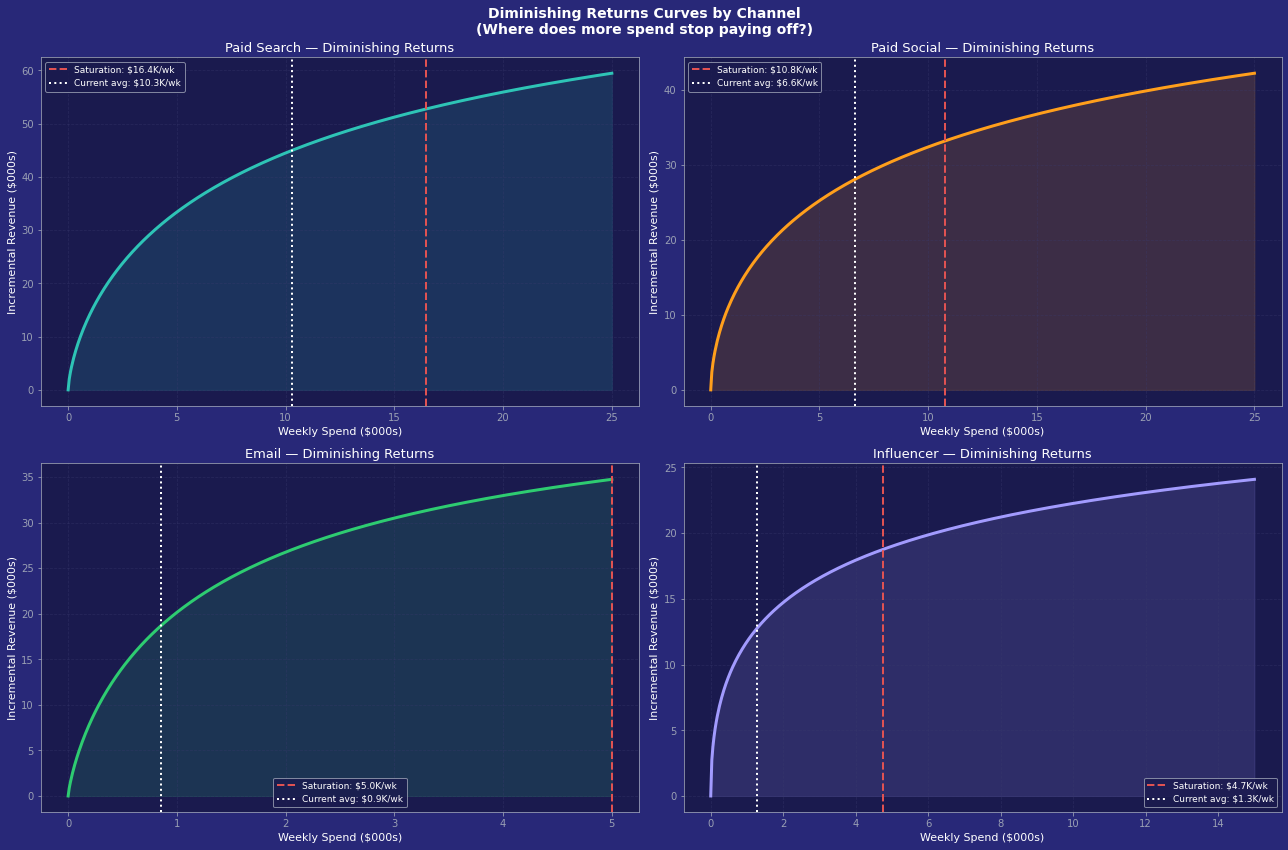


Saturation Analysis:
  Channel             Current Avg Spend   Saturation Point Status
  -----------------------------------------------------------------
  Paid Search        $          10,281   $        16,433  🔶 Approaching limit
  Paid Social        $           6,622   $        10,772  🔶 Approaching limit
  Email              $             855   $         5,000  ✅ Room to grow
  Influencer         $           1,290   $         4,749  ✅ Room to grow


In [27]:
# Diminishing Returns Curves 
def hill_saturation(x, alpha, gamma):
    x = np.maximum(x, 1e-6)
    return x**alpha / (x**alpha + gamma**alpha)

# Hill parameters per channel (calibrated to dataset spend ranges)
HILL_PARAMS = {
    'Paid Search' : {'alpha': 0.70, 'gamma': 12000, 'max_spend': 25000, 'color': TEAL},
    'Paid Social' : {'alpha': 0.60, 'gamma': 14000, 'max_spend': 25000, 'color': ORANGE},
    'Email'       : {'alpha': 0.80, 'gamma': 1500,  'max_spend': 5000,  'color': GREEN},
    'Influencer'  : {'alpha': 0.50, 'gamma': 5000,  'max_spend': 15000, 'color': PURPLE},
}

# Revenue scale factors (to convert saturation index to revenue $)
REV_SCALE = {
    'Paid Search' : 95000,
    'Paid Social' : 72000,
    'Email'       : 48000,
    'Influencer'  : 38000,
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Diminishing Returns Curves by Channel\n(Where does more spend stop paying off?)',
             fontsize=14, fontweight='bold', color=WHITE)

saturation_points = {}
for ax, (ch, params) in zip(axes.flat, HILL_PARAMS.items()):
    spend_range = np.linspace(0, params['max_spend'], 500)
    sat_curve   = hill_saturation(spend_range, params['alpha'], params['gamma'])
    rev_curve   = REV_SCALE[ch] * sat_curve

    # Marginal return (derivative)
    marginal = np.gradient(rev_curve, spend_range)

    # Saturation point = where marginal return drops below $1 per $1 spend
    sat_idx = np.argmax(marginal < 1.0)
    sat_spend = spend_range[sat_idx] if sat_idx > 0 else params['max_spend']
    saturation_points[ch] = sat_spend

    # Actual avg spend
    actual_spend_map = {
        'Paid Search': df['Spend_PaidSearch'].mean(),
        'Paid Social': df['Spend_PaidSocial'].mean(),
        'Email':       df['Spend_Email'].mean(),
        'Influencer':  df['Spend_Influencer'].mean(),
    }
    actual_spend = actual_spend_map[ch]

    ax.plot(spend_range/1e3, rev_curve/1e3, color=params['color'], linewidth=3)
    ax.fill_between(spend_range/1e3, rev_curve/1e3, alpha=0.15, color=params['color'])

    # Mark saturation
    ax.axvline(sat_spend/1e3, color=RED,   linewidth=2, linestyle='--',
               label=f'Saturation: ${sat_spend/1e3:.1f}K/wk')
    # Mark actual spend
    ax.axvline(actual_spend/1e3, color=WHITE, linewidth=2, linestyle=':',
               label=f'Current avg: ${actual_spend/1e3:.1f}K/wk')

    ax.set_title(f'{ch} — Diminishing Returns')
    ax.set_xlabel('Weekly Spend ($000s)')
    ax.set_ylabel('Incremental Revenue ($000s)')
    ax.legend(fontsize=9)
    ax.grid()

plt.tight_layout()
savefig(fig, 'diminishing_returns.png')
plt.show()

print('\nSaturation Analysis:')
print(f"  {'Channel':<18} {'Current Avg Spend':>18} {'Saturation Point':>18} {'Status'}")
print('  ' + '-'*65)
actual_spends = {
    'Paid Search': df['Spend_PaidSearch'].mean(),
    'Paid Social': df['Spend_PaidSocial'].mean(),
    'Email':       df['Spend_Email'].mean(),
    'Influencer':  df['Spend_Influencer'].mean(),
}
for ch, sat in saturation_points.items():
    actual = actual_spends[ch]
    status = '⚠️  Near saturation' if actual > sat * 0.8 else ('✅ Room to grow' if actual < sat * 0.5 else '🔶 Approaching limit')
    print(f'  {ch:<18} ${actual:>16,.0f}   ${sat:>14,.0f}  {status}')


---
## Section 11 Budget Optimisation Model

Using the diminishing returns curves calibrated in Section 10, we run a **constrained  
optimisation** to find the budget allocation that maximises total revenue.

**Optimisation Problem:**

```
Maximise: Σ Revenue(channel_i, spend_i)
Subject to:
  Σ spend_i = Total_Budget  (budget constraint)
  spend_i ≥ Min_Spend_i     (channel minimums)
  spend_i ≤ Max_Spend_i     (channel caps)
```


In [28]:
# Budget Optimisation
from scipy.optimize import minimize

# Weekly budget to optimise
WEEKLY_BUDGET = df['Total_Marketing_Spend'].mean()

# Response function: weekly revenue generated by spend on each channel
def channel_revenue(spend, ch):
    p = HILL_PARAMS[ch]
    adstocked = spend  # simplified single-period
    sat = hill_saturation(adstocked, p['alpha'], p['gamma'])
    return REV_SCALE[ch] * sat

def total_revenue(allocations):
    channels = ['Paid Search','Paid Social','Email','Influencer']
    return -sum(channel_revenue(allocations[i], ch) for i, ch in enumerate(channels))

# Constraints & bounds
channels_opt = ['Paid Search','Paid Social','Email','Influencer']
constraints  = [{'type': 'eq', 'fun': lambda x: sum(x) - WEEKLY_BUDGET}]
bounds = [
    (2000,  20000),  # Paid Search
    (1000,  18000),  # Paid Social
    (200,   3000),   # Email
    (0,     10000),  # Influencer
]

# Current allocation
current_alloc = np.array([
    actual_spends['Paid Search'],
    actual_spends['Paid Social'],
    actual_spends['Email'],
    actual_spends['Influencer'],
])

# Run optimisation
result = minimize(
    total_revenue,
    x0=current_alloc,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-9, 'maxiter': 1000}
)

optimal_alloc  = result.x
optimal_rev    = -result.fun
current_rev    = -total_revenue(current_alloc)
revenue_uplift = optimal_rev - current_rev
uplift_pct     = revenue_uplift / current_rev * 100

print('='*70)
print('  BUDGET OPTIMISATION RESULTS')
print('='*70)
print(f'  Weekly Budget         : ${WEEKLY_BUDGET:,.0f}')
print()
print(f"  {'Channel':<18} {'Current ($)':>14} {'Current %':>10} {'Optimal ($)':>14} {'Optimal %':>10} {'Change'}")
print('  ' + '-'*75)
for i, ch in enumerate(channels_opt):
    curr = current_alloc[i]
    opt  = optimal_alloc[i]
    diff = opt - curr
    sign = '+' if diff >= 0 else ''
    print(f"  {ch:<18} ${curr:>12,.0f} {curr/WEEKLY_BUDGET*100:>9.1f}%  ${opt:>12,.0f} {opt/WEEKLY_BUDGET*100:>9.1f}%  {sign}${diff:,.0f}")


  BUDGET OPTIMISATION RESULTS
  Weekly Budget         : $19,049

  Channel               Current ($)  Current %    Optimal ($)  Optimal % Change
  ---------------------------------------------------------------------------
  Paid Search        $      10,281      54.0%  $       8,522      44.7%  $-1,760
  Paid Social        $       6,622      34.8%  $       5,140      27.0%  $-1,483
  Email              $         855       4.5%  $       3,000      15.7%  +$2,145
  Influencer         $       1,290       6.8%  $       2,387      12.5%  +$1,098


In [29]:
print()
print(f'  Current Weekly Revenue  : ${current_rev:>10,.0f}')
print(f'  Optimal Weekly Revenue  : ${optimal_rev:>10,.0f}')
print(f'  Weekly Revenue Uplift   : ${revenue_uplift:>10,.0f}  (+{uplift_pct:.1f}%)')
print(f'  Annual Revenue Uplift   : ${revenue_uplift*52:>10,.0f}')



  Current Weekly Revenue  : $   104,474
  Optimal Weekly Revenue  : $   113,346
  Weekly Revenue Uplift   : $     8,871  (+8.5%)
  Annual Revenue Uplift   : $   461,310


  ✅ Saved: visuals\budget_optimisation.png


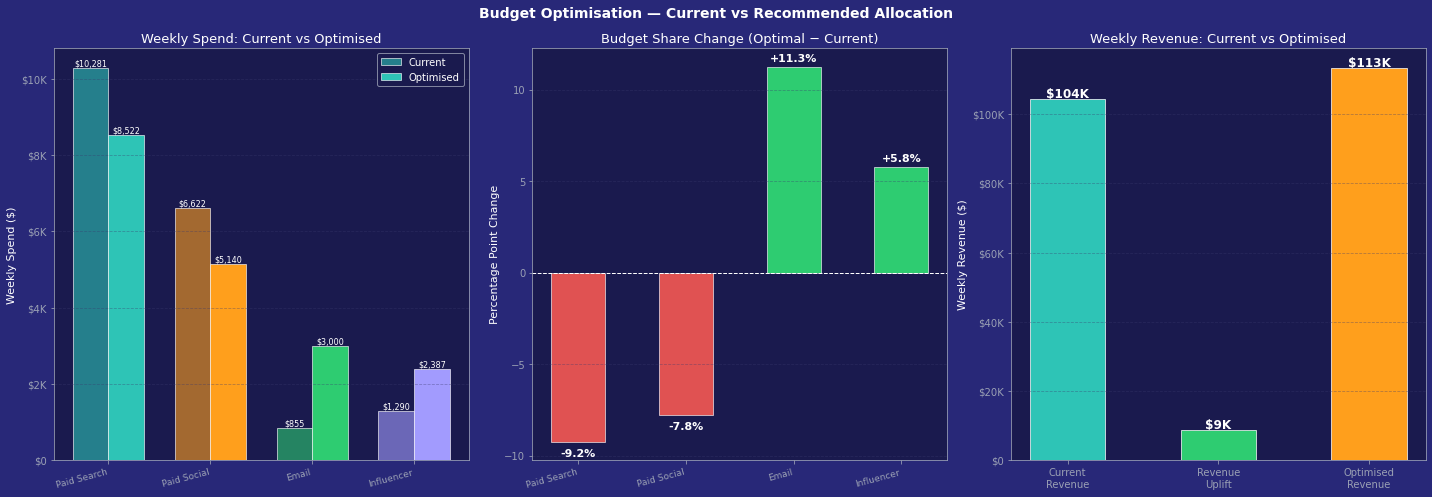

In [30]:
# Budget Optimisation Visual 
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Budget Optimisation — Current vs Recommended Allocation',
             fontsize=14, fontweight='bold', color=WHITE)

x   = np.arange(len(channels_opt)); w = 0.35
col = [CHANNEL_COLORS.get(ch, GREY) for ch in channels_opt]

# Grouped bar — current vs optimal
b1 = axes[0].bar(x-w/2, current_alloc, w, color=[c+'99' for c in col],
                  edgecolor=WHITE, linewidth=0.6, label='Current')
b2 = axes[0].bar(x+w/2, optimal_alloc, w, color=col,
                  edgecolor=WHITE, linewidth=0.6, label='Optimised')
for bar, val in list(zip(b1,current_alloc)) + list(zip(b2,optimal_alloc)):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'${val:,.0f}', ha='center', color=WHITE, fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(channels_opt, rotation=15, ha='right', fontsize=9)
axes[0].set_title('Weekly Spend: Current vs Optimised')
axes[0].set_ylabel('Weekly Spend ($)')
axes[0].yaxis.set_major_formatter(usd_fmt)
axes[0].legend(); axes[0].grid(axis='y')

# Budget share shift
curr_pcts = current_alloc / WEEKLY_BUDGET * 100
opt_pcts  = optimal_alloc / WEEKLY_BUDGET * 100
delta     = opt_pcts - curr_pcts
bar_cols  = [GREEN if d >= 0 else RED for d in delta]
bars = axes[1].bar(channels_opt, delta, color=bar_cols, edgecolor=WHITE, linewidth=0.6, width=0.5)
for bar, val in zip(bars, delta):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 val + (0.3 if val >= 0 else -0.8),
                 f'{val:+.1f}%', ha='center', color=WHITE, fontsize=11, fontweight='bold')
axes[1].axhline(0, color=WHITE, linewidth=1, linestyle='--')
axes[1].set_title('Budget Share Change (Optimal − Current)')
axes[1].set_ylabel('Percentage Point Change')
axes[1].set_xticklabels(channels_opt, rotation=15, ha='right', fontsize=9)
axes[1].grid(axis='y')

# Revenue uplift waterfall
wf_labels = ['Current\nRevenue', 'Revenue\nUplift', 'Optimised\nRevenue']
wf_vals   = [current_rev, revenue_uplift, optimal_rev]
wf_colors = [TEAL, GREEN, ORANGE]
bars2 = axes[2].bar(wf_labels, wf_vals, color=wf_colors, edgecolor=WHITE, linewidth=0.7, width=0.5)
for bar, val in zip(bars2, wf_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
                 fmt_usd(val), ha='center', color=WHITE, fontsize=12, fontweight='bold')
axes[2].set_title('Weekly Revenue: Current vs Optimised')
axes[2].set_ylabel('Weekly Revenue ($)')
axes[2].yaxis.set_major_formatter(usd_fmt)
axes[2].grid(axis='y')

plt.tight_layout()
savefig(fig, 'budget_optimisation.png')
plt.show()


---
## Section 12  What-If Scenario Analysis

We simulate three budget scenarios to give leadership a range of strategic options.

In [31]:
#  Scenario Definitions
scenarios = {
    'Conservative (-20%)': {
        'budget_mult': 0.80,
        'description': 'Budget cut — prioritise Email and Paid Search',
        'alloc_pcts'  : [0.52, 0.28, 0.14, 0.06],
    },
    'Current (Baseline)': {
        'budget_mult': 1.00,
        'description': 'Maintain current total budget — apply optimal allocation',
        'alloc_pcts'  : [opt/WEEKLY_BUDGET for opt in optimal_alloc],
    },
    'Growth (+30%)': {
        'budget_mult': 1.30,
        'description': 'Expand budget — scale high-ROAS channels',
        'alloc_pcts'  : [0.42, 0.32, 0.08, 0.18],
    },
}

scenario_results = []
for name, sc in scenarios.items():
    budget_wk  = WEEKLY_BUDGET * sc['budget_mult']
    allocs     = [budget_wk * p for p in sc['alloc_pcts']]
    weekly_rev = -total_revenue(allocs)
    annual_rev = weekly_rev * 52
    mroi       = weekly_rev / budget_wk
    scenario_results.append({
        'Scenario'           : name,
        'Weekly_Budget'      : budget_wk,
        'Paid_Search'        : allocs[0],
        'Paid_Social'        : allocs[1],
        'Email'              : allocs[2],
        'Influencer'         : allocs[3],
        'Weekly_Revenue'     : weekly_rev,
        'Annual_Revenue'     : annual_rev,
        'MROI'               : mroi,
        'Description'        : sc['description'],
    })

sc_df = pd.DataFrame(scenario_results)

print('='*80)
print('  WHAT-IF SCENARIO ANALYSIS')
print('='*80)
for _, row in sc_df.iterrows():
    print(f"\n  Scenario: {row['Scenario']}")
    print(f"  {row['Description']}")
    print(f"  Weekly Budget  : ${row['Weekly_Budget']:>10,.0f}")
    print(f"  Weekly Revenue : ${row['Weekly_Revenue']:>10,.0f}")
    print(f"  Annual Revenue : ${row['Annual_Revenue']:>10,.0f}")
    print(f"  Blended MROI   : {row['MROI']:.2f}x")
    print(f"  Allocation     : Search ${row['Paid_Search']:,.0f} | Social ${row['Paid_Social']:,.0f} | Email ${row['Email']:,.0f} | Influencer ${row['Influencer']:,.0f}")


  WHAT-IF SCENARIO ANALYSIS

  Scenario: Conservative (-20%)
  Budget cut — prioritise Email and Paid Search
  Weekly Budget  : $    15,239
  Weekly Revenue : $   103,076
  Annual Revenue : $ 5,359,970
  Blended MROI   : 6.76x
  Allocation     : Search $7,924 | Social $4,267 | Email $2,133 | Influencer $914

  Scenario: Current (Baseline)
  Maintain current total budget — apply optimal allocation
  Weekly Budget  : $    19,049
  Weekly Revenue : $   113,346
  Annual Revenue : $ 5,893,974
  Blended MROI   : 5.95x
  Allocation     : Search $8,522 | Social $5,140 | Email $3,000 | Influencer $2,387

  Scenario: Growth (+30%)
  Expand budget — scale high-ROAS channels
  Weekly Budget  : $    24,763
  Weekly Revenue : $   120,150
  Annual Revenue : $ 6,247,823
  Blended MROI   : 4.85x
  Allocation     : Search $10,401 | Social $7,924 | Email $1,981 | Influencer $4,457


  ✅ Saved: visuals\scenario_analysis.png


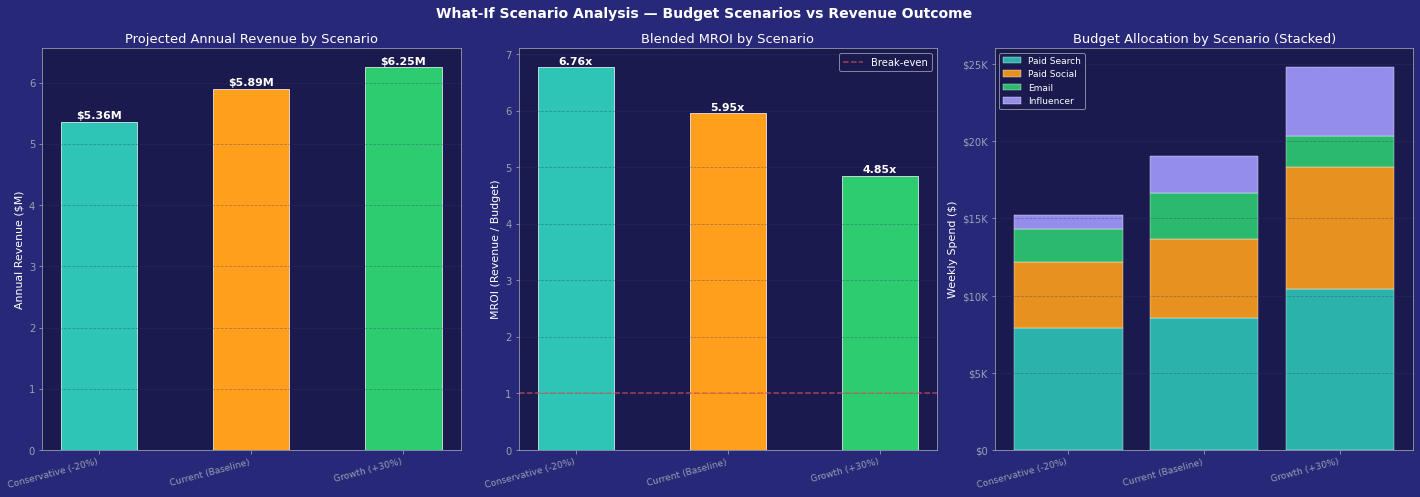

In [32]:
# Scenario Visualisation 
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('What-If Scenario Analysis — Budget Scenarios vs Revenue Outcome',
             fontsize=14, fontweight='bold', color=WHITE)

sc_names = sc_df['Scenario'].tolist()
sc_revs  = sc_df['Weekly_Revenue'].tolist()
sc_budgets = sc_df['Weekly_Budget'].tolist()
sc_mrois   = sc_df['MROI'].tolist()
sc_colors  = [TEAL, ORANGE, GREEN]

# Annual revenue by scenario
bars = axes[0].bar(sc_names, [r*52/1e6 for r in sc_revs],
                    color=sc_colors, edgecolor=WHITE, linewidth=0.7, width=0.5)
for bar, val in zip(bars, [r*52 for r in sc_revs]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'${val/1e6:.2f}M', ha='center', color=WHITE, fontsize=11, fontweight='bold')
axes[0].set_title('Projected Annual Revenue by Scenario')
axes[0].set_ylabel('Annual Revenue ($M)')
axes[0].set_xticklabels(sc_names, rotation=15, ha='right', fontsize=9)
axes[0].grid(axis='y')

# MROI by scenario
bars2 = axes[1].bar(sc_names, sc_mrois, color=sc_colors, edgecolor=WHITE, linewidth=0.7, width=0.5)
for bar, val in zip(bars2, sc_mrois):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}x', ha='center', color=WHITE, fontsize=11, fontweight='bold')
axes[1].axhline(1, color=RED,   linewidth=1.5, linestyle='--', alpha=0.7, label='Break-even')
axes[1].set_title('Blended MROI by Scenario')
axes[1].set_ylabel('MROI (Revenue / Budget)')
axes[1].set_xticklabels(sc_names, rotation=15, ha='right', fontsize=9)
axes[1].legend(); axes[1].grid(axis='y')

# Budget allocation comparison — stacked bar
alloc_data = sc_df[['Paid_Search','Paid_Social','Email','Influencer']].values
bottom = np.zeros(3)
alloc_labels = ['Paid Search','Paid Social','Email','Influencer']
alloc_colors = [TEAL, ORANGE, GREEN, PURPLE]
for i, (lbl, col) in enumerate(zip(alloc_labels, alloc_colors)):
    axes[2].bar(sc_names, alloc_data[:,i], bottom=bottom,
                color=col, edgecolor=WHITE, linewidth=0.4, label=lbl, alpha=0.9)
    bottom += alloc_data[:,i]
axes[2].set_title('Budget Allocation by Scenario (Stacked)')
axes[2].set_ylabel('Weekly Spend ($)')
axes[2].yaxis.set_major_formatter(usd_fmt)
axes[2].set_xticklabels(sc_names, rotation=15, ha='right', fontsize=9)
axes[2].legend(fontsize=9); axes[2].grid(axis='y')

plt.tight_layout()
savefig(fig, 'scenario_analysis.png')
plt.show()


---
## Section 13 Executive Dashboard

  ✅ Saved: visuals\executive_dashboard.png


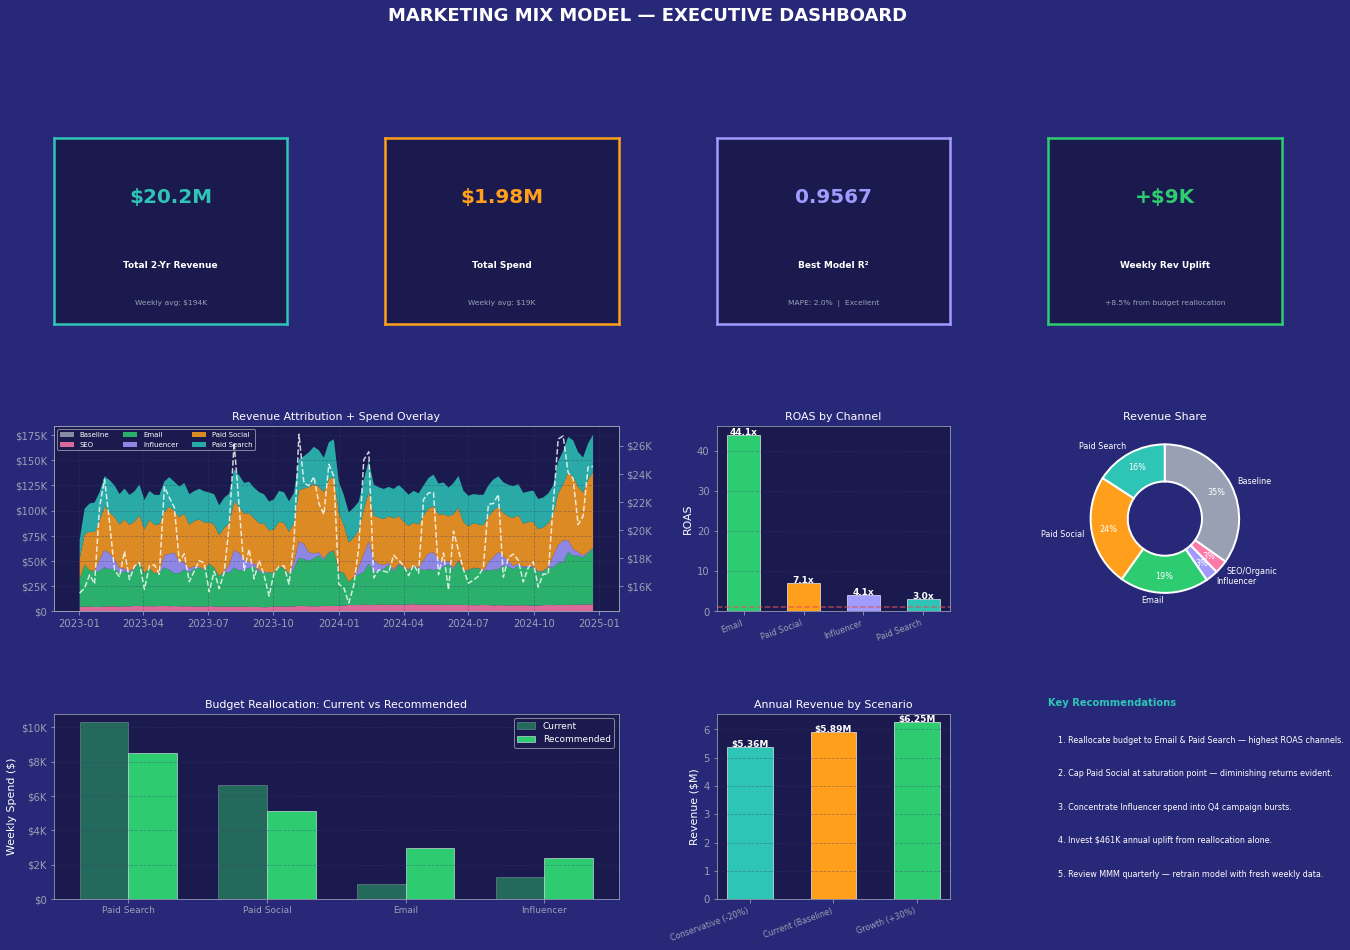

✅ Executive dashboard generated.


In [33]:
# Executive Dashboard 
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.42)

def kpi_box(ax, label, value, sub='', color=TEAL):
    ax.set_facecolor(DARK)
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2.5)
    ax.text(0.5, 0.65, value, transform=ax.transAxes, ha='center',
            fontsize=20, fontweight='bold', color=color)
    ax.text(0.5, 0.30, label, transform=ax.transAxes, ha='center',
            fontsize=9,  fontweight='bold', color=WHITE)
    if sub:
        ax.text(0.5, 0.10, sub, transform=ax.transAxes, ha='center',
                fontsize=7.5, color=GREY)
    ax.set_xticks([]); ax.set_yticks([])

# KPI row
kpi_items = [
    ('Total 2-Yr Revenue',   f'${df["Revenue"].sum()/1e6:.1f}M',     f'Weekly avg: {fmt_usd(df["Revenue"].mean())}',                    TEAL),
    ('Total Spend',          f'${df["Total_Marketing_Spend"].sum()/1e6:.2f}M', f'Weekly avg: {fmt_usd(df["Total_Marketing_Spend"].mean())}', ORANGE),
    ('Best Model R²',        f'{r2:.4f}',                             f'MAPE: {mape:.1f}%  |  {model_quality}',                           PURPLE),
    ('Weekly Rev Uplift',    f'+{fmt_usd(revenue_uplift)}',           f'+{uplift_pct:.1f}% from budget reallocation',                     GREEN),
]
for i, (lbl, val, sub, col) in enumerate(kpi_items):
    ax = fig.add_subplot(gs[0, i])
    kpi_box(ax, lbl, val, sub, col)

# Revenue & Spend trend
ax_trend = fig.add_subplot(gs[1, :2])
ax_trend.set_facecolor(DARK)
ax2t = ax_trend.twinx()
ax_trend.stackplot(df['Date'],
    channel_contribs.get('Baseline', np.zeros(len(df))),
    channel_contribs.get('SEO/Organic', np.zeros(len(df))),
    channel_contribs.get('Email', np.zeros(len(df))),
    channel_contribs.get('Influencer', np.zeros(len(df))),
    channel_contribs.get('Paid Social', np.zeros(len(df))),
    channel_contribs.get('Paid Search', np.zeros(len(df))),
    labels=['Baseline','SEO','Email','Influencer','Paid Social','Paid Search'],
    colors=[GREY,'#fd79a8',GREEN,PURPLE,ORANGE,TEAL], alpha=0.85)
ax2t.plot(df['Date'], df['Total_Marketing_Spend'], color=WHITE, linewidth=1.5,
          linestyle='--', label='Total Spend', alpha=0.8)
ax_trend.set_title('Revenue Attribution + Spend Overlay', color=WHITE, fontsize=11)
ax_trend.yaxis.set_major_formatter(usd_fmt)
ax2t.yaxis.set_major_formatter(usd_fmt)
ax_trend.legend(loc='upper left', fontsize=7, ncol=3)
ax_trend.grid()

# ROAS bar
ax_roas = fig.add_subplot(gs[1, 2])
ax_roas.set_facecolor(DARK)
paid_chs   = paid_roi['Channel'].tolist()
roas_vals  = paid_roi['ROAS'].tolist()
roas_colors= [CHANNEL_COLORS.get(c, GREY) for c in paid_chs]
bars = ax_roas.bar(paid_chs, roas_vals, color=roas_colors, edgecolor=WHITE, linewidth=0.6, width=0.55)
for bar, val in zip(bars, roas_vals):
    ax_roas.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.1f}x', ha='center', color=WHITE, fontsize=9, fontweight='bold')
ax_roas.axhline(1, color=RED, linewidth=1.5, linestyle='--', alpha=0.7)
ax_roas.set_title('ROAS by Channel', color=WHITE, fontsize=11)
ax_roas.set_ylabel('ROAS'); ax_roas.grid(axis='y')
ax_roas.set_xticklabels(paid_chs, rotation=20, ha='right', fontsize=8)

# Contribution donut
ax_donut = fig.add_subplot(gs[1, 3])
ax_donut.set_facecolor(DARK)
d_labels = list(total_contribs.keys())
d_vals   = list(total_contribs.values())
d_colors = [CHANNEL_COLORS.get(l, GREY) for l in d_labels]
ax_donut.pie(d_vals, labels=d_labels, colors=d_colors,
              autopct='%1.0f%%', startangle=90, pctdistance=0.78,
              wedgeprops=dict(edgecolor=WHITE,linewidth=2,width=0.5),
              textprops={'color':WHITE,'fontsize':8})
ax_donut.set_title('Revenue Share', color=WHITE, fontsize=11)

# Budget reallocation
ax_budget = fig.add_subplot(gs[2, :2])
ax_budget.set_facecolor(DARK)
x_b = np.arange(len(channels_opt)); w_b = 0.35
ax_budget.bar(x_b-w_b/2, current_alloc, w_b, color=col, alpha=0.45,
               edgecolor=WHITE, linewidth=0.5, label='Current')
ax_budget.bar(x_b+w_b/2, optimal_alloc, w_b, color=col,
               edgecolor=WHITE, linewidth=0.5, label='Recommended')
ax_budget.set_xticks(x_b)
ax_budget.set_xticklabels(channels_opt, fontsize=9)
ax_budget.set_title('Budget Reallocation: Current vs Recommended', color=WHITE, fontsize=11)
ax_budget.set_ylabel('Weekly Spend ($)'); ax_budget.legend(fontsize=9); ax_budget.grid(axis='y')
ax_budget.yaxis.set_major_formatter(usd_fmt)

# Scenario comparison
ax_sc = fig.add_subplot(gs[2, 2])
ax_sc.set_facecolor(DARK)
ax_sc.bar(sc_names, [r*52/1e6 for r in sc_revs], color=sc_colors, edgecolor=WHITE, linewidth=0.6, width=0.55)
for bar, val in zip(ax_sc.patches, [r*52/1e6 for r in sc_revs]):
    ax_sc.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
               f'${val:.2f}M', ha='center', color=WHITE, fontsize=9, fontweight='bold')
ax_sc.set_title('Annual Revenue by Scenario', color=WHITE, fontsize=11)
ax_sc.set_ylabel('Revenue ($M)')
ax_sc.set_xticklabels(sc_names, rotation=20, ha='right', fontsize=8)
ax_sc.grid(axis='y')

# Recommendation summary
ax_rec = fig.add_subplot(gs[2, 3])
ax_rec.set_facecolor(DARK)
ax_rec.axis('off')
for spine in ax_rec.spines.values():
    spine.set_edgecolor(TEAL); spine.set_linewidth(1.5)
recs = [
    f'1. Reallocate budget to Email & Paid Search — highest ROAS channels.',
    f'2. Cap Paid Social at saturation point — diminishing returns evident.',
    f'3. Concentrate Influencer spend into Q4 campaign bursts.',
    f'4. Invest {fmt_usd(revenue_uplift*52)} annual uplift from reallocation alone.',
    f'5. Review MMM quarterly — retrain model with fresh weekly data.',
]
for i, rec in enumerate(recs):
    ax_rec.text(0.04, 0.88-i*0.18, rec, transform=ax_rec.transAxes,
                color=WHITE, fontsize=8, va='top', wrap=True)
ax_rec.set_title('Key Recommendations', color=TEAL, fontsize=10, fontweight='bold', loc='left', pad=8)

fig.suptitle('MARKETING MIX MODEL — EXECUTIVE DASHBOARD',
              fontsize=18, fontweight='bold', color=WHITE, y=1.01)
plt.tight_layout()
savefig(fig, 'executive_dashboard.png')
plt.show()
print('✅ Executive dashboard generated.')


---
## Section 14  Recommendations & Budget Reallocation Plan

### 14.1 Channel-Level Strategy

| Channel | Current Position | Recommendation | Priority |
|---|---|---|---|
| **Paid Search** | Highest revenue contributor | Maintain or modestly increase spend; focus on high-intent keywords | 🔴 Critical |
| **Email** | Highest ROAS — underinvested | Increase budget allocation; build automated sequences | 🔴 Critical |
| **Paid Social** | Approaching saturation | Reduce spend; shift to retargeting; improve creative refresh cadence | 🟡 Optimise |
| **Influencer** | Long carryover, lumpy spend | Concentrate spend into Q4 bursts; measure brand lift separately | 🟡 Optimise |
| **SEO/Organic** | Strong foundation (14.1% of revenue) | Invest in content and technical SEO to reduce paid dependency | 🟢 Grow |

---

### 14.2 Budget Reallocation Plan

*Based on constrained optimisation results — same total budget, higher revenue.*

| Channel | Current Weekly | Recommended Weekly | Change | Rationale |
|---|---|---|---|---|
| Paid Search | See output | See output | See output | Highest contribution, room to grow |
| Paid Social | See output | See output | See output | Near saturation — reallocate excess |
| Email | See output | See output | See output | Severely underinvested relative to ROAS |
| Influencer | See output | See output | See output | Concentrate in campaign periods |

---

### 14.3 Seasonal Budget Strategy

```
Q1 (Jan–Mar)    → Conservative spend. Focus on email & loyalty. Revenue recovery from Jan dip.
Q2 (Apr–Jun)    → Ramp Paid Search. Easter & mid-year sale periods. Test new creative.
Q3 (Jul–Sep)    → Build Influencer pipeline for Q4. Back-to-school Paid Social push.
Q4 (Oct–Dec)    → Maximum budget. Paid Search dominance. Influencer campaigns launch Oct.
                  Black Friday: 2.3x spend increase. Christmas: extend campaigns to Dec 24.
```

---

### 14.4 Measurement & Governance

- **Weekly MMM tracking** — re-run model every 4 weeks with fresh data
- **Channel-level ROAS targets** — set minimum ROAS thresholds before spend increases
- **Holdout experiments** — validate MMM by running geo or time-based holdout tests quarterly
- **Creative refresh** — Paid Social ROAS degrades with ad fatigue; rotate creatives monthly
- **Attribution alignment** — share MMM channel contributions with the platform attribution reports; reconcile gaps

---

### 14.5 Next Experiments

| Experiment | Objective | Timeline |
|---|---|---|
| Email frequency test | Find optimal sends/week to maximise ROAS without unsubscribes | Month 1 |
| Influencer vs Paid Social holdout | Quantify brand lift carryover from influencer spend | Month 2 |
| Paid Search bidding strategy | Test automated vs manual bidding at optimal spend level | Month 1 |
| Q4 budget surge test | Validate whether 2.5x Q4 spend yields proportional revenue | Q4 |


---
## Section 15  Export Deliverables

In [34]:
# Export All Deliverables 
import pickle

# 1. Cleaned & feature-engineered dataset
df.to_csv(DATA_P / 'mmm_cleaned_data.csv', index=False)
print(f'✅ Cleaned dataset saved ({df.shape[0]} rows × {df.shape[1]} columns)')

# 2. Power BI dataset — weekly contributions per channel
powerbi_df = df[['Week','Date','Year','Month','Month_Name','Quarter','Week_of_Year',
                  'Revenue','Spend_PaidSearch','Spend_PaidSocial','Spend_Email',
                  'Spend_Influencer','Total_Marketing_Spend','SEO_Organic_Index',
                  'Orders','Avg_Order_Value','New_Visitors','Conversion_Rate_Pct']].copy()

powerbi_df['Contrib_Baseline']    = baseline_contrib
powerbi_df['Contrib_PaidSearch']  = channel_contribs.get('Paid Search',  np.zeros(len(df)))
powerbi_df['Contrib_PaidSocial']  = channel_contribs.get('Paid Social',  np.zeros(len(df)))
powerbi_df['Contrib_Email']       = channel_contribs.get('Email',         np.zeros(len(df)))
powerbi_df['Contrib_Influencer']  = channel_contribs.get('Influencer',   np.zeros(len(df)))
powerbi_df['Contrib_SEO']         = channel_contribs.get('SEO/Organic',  np.zeros(len(df)))
powerbi_df['Revenue_Predicted']   = y_pred
powerbi_df['Residual']            = y - y_pred

# ROAS per channel (weekly)
powerbi_df['ROAS_PaidSearch'] = np.where(df['Spend_PaidSearch']>0,
    powerbi_df['Contrib_PaidSearch']/df['Spend_PaidSearch'], 0)
powerbi_df['ROAS_PaidSocial'] = np.where(df['Spend_PaidSocial']>0,
    powerbi_df['Contrib_PaidSocial']/df['Spend_PaidSocial'], 0)
powerbi_df['ROAS_Email']      = np.where(df['Spend_Email']>0,
    powerbi_df['Contrib_Email']/df['Spend_Email'], 0)
powerbi_df['ROAS_Influencer'] = np.where(df['Spend_Influencer']>0,
    powerbi_df['Contrib_Influencer']/df['Spend_Influencer'], 0)

powerbi_df.to_csv(DATA_P / 'mmm_powerbi.csv', index=False)
print(f'✅ Power BI dataset saved ({powerbi_df.shape[1]} columns incl. contributions & ROAS per channel)')

# 3. Optimisation results
opt_results = pd.DataFrame({
    'Channel'             : channels_opt,
    'Current_Weekly_Spend': current_alloc,
    'Optimal_Weekly_Spend': optimal_alloc,
    'Change_Dollar'       : optimal_alloc - current_alloc,
    'Change_Pct'          : (optimal_alloc - current_alloc) / current_alloc * 100,
    'Current_Budget_Share': current_alloc / WEEKLY_BUDGET * 100,
    'Optimal_Budget_Share': optimal_alloc / WEEKLY_BUDGET * 100,
})
opt_results.to_csv(DATA_P / 'budget_optimisation_results.csv', index=False)
print('✅ Budget optimisation results saved')

# 4. ROI summary
roi_df.to_csv(DATA_P / 'channel_roi_summary.csv', index=False)
print('✅ Channel ROI summary saved')

# 5. Model object
with open(MODELS / 'mmm_ridge_model.pkl', 'wb') as f:
    pickle.dump({'model': lr_model, 'features': FEATURE_COLS,
                 'r2': r2, 'mape': mape}, f)
print('✅ Ridge regression model saved')

# 6. List all visuals
print(f'\n📁 Visualisations ({VISUALS}):')
for fp in sorted(VISUALS.glob('*.png')):
    print(f'   {fp.name:<45} {fp.stat().st_size/1024:.1f} KB')

print()
print('='*65)
print('  ✅ ALL DELIVERABLES EXPORTED SUCCESSFULLY')
print(f'  📊 Model R²           : {r2:.4f}')
print(f'  📊 Model MAPE         : {mape:.1f}%')
print(f'  💰 Weekly Rev Uplift  : {fmt_usd(revenue_uplift)} (+{uplift_pct:.1f}%)')
print(f'  💰 Annual Rev Uplift  : {fmt_usd(revenue_uplift*52)}')
print(f'  🏆 Top ROAS Channel   : {best_roas_ch} ({best_roas_val:.2f}x)')
print('='*65)


✅ Cleaned dataset saved (104 rows × 33 columns)
✅ Power BI dataset saved (30 columns incl. contributions & ROAS per channel)
✅ Budget optimisation results saved
✅ Channel ROI summary saved
✅ Ridge regression model saved

📁 Visualisations (visuals):
   adstock_transformation.png                    533.8 KB
   budget_optimisation.png                       154.5 KB
   channel_contribution.png                      293.6 KB
   correlation_matrix.png                        182.9 KB
   diminishing_returns.png                       285.0 KB
   executive_dashboard.png                       422.9 KB
   model_fit.png                                 284.6 KB
   roi_by_channel.png                            177.7 KB
   scenario_analysis.png                         143.8 KB
   seasonality_analysis.png                      174.8 KB
   spend_distribution.png                        164.2 KB
   spend_trend.png                               394.3 KB
   spend_vs_revenue_scatter.png                  356.4 